In [74]:
import pandas as pd
import gc

file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
train_df   = pd.read_csv(file_loc + 'train_df.csv')
holdout_df = pd.read_csv(file_loc + 'holdout_df.csv')

# drop all long_profit / short_profit variables
drop_cols = [c for c in train_df.columns if 'long_profit_' in c or 'short_profit_' in c]
train_df   = train_df.drop(columns=drop_cols)
holdout_df = holdout_df.drop(columns=[c for c in drop_cols if c in holdout_df.columns])
print('dropped', len(drop_cols), 'cols:', drop_cols)

print('train_df  :', train_df.shape)
print('holdout_df:', holdout_df.shape)
train_df.head()


dropped 10 cols: ['long_profit_sum_3d', 'short_profit_sum_3d', 'long_profit_sum_7d', 'short_profit_sum_7d', 'long_profit_sum_1m', 'short_profit_sum_1m', 'long_profit_sum_3m', 'short_profit_sum_3m', 'long_profit_sum_1y', 'short_profit_sum_1y']
train_df  : (603721, 70)
holdout_df: (231724, 70)


,constraint_family_num,dt,profit,profit_congestion,long_profit,short_profit,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,...,rt_nz_cnt_1y,rt_nz_cnt_3y,rt_spike_7d,rt_spike_1m,rt_spike_3m,rt_spike_1y,rt_spike_3y,KV,KV_group,monitored_name
0,7,2021-07-01,14353.11877,5089.66448,0.0,0.0,0.405322,0.0,0.0,-104.0,...,0.0,3.0,0.0,0.000000,0.000000,0.000000,-852.205775,161.0,04_345,ln70_bluf-sub1214
1,11,2021-07-01,3893.43353,-828.00122,0.0,0.0,0.568018,0.0,0.0,-201.0,...,5.0,5.0,0.0,-2829.423183,-2894.467394,-1825.074444,-1841.973281,161.0,04_345,lnadabell-vbi5
2,20,2021-07-01,2606.85200,82.42028,0.0,0.0,0.440639,0.0,0.0,-108.0,...,1.0,1.0,0.0,0.000000,-876.909880,-884.333313,-885.952971,NaN,03_138,lnallen2-quaker
3,27,2021-07-01,2922.76579,160.79166,0.0,0.0,NaN,NaN,NaN,NaN,...,0.0,30.0,0.0,0.000000,0.000000,0.000000,-909.199441,NaN,03_138,lnanadarko-pocaset
4,28,2021-07-01,10621.29462,2009.66464,0.0,0.0,0.361810,0.0,0.0,-194.0,...,0.0,1.0,0.0,0.000000,0.000000,0.000000,-228.905063,138.0,03_138,lnanadarko-sequoyah


In [75]:
import sys; sys.path.append('/var/www/python/Prod/nighthawk/')
import pandas as pd
from nighthawk.data.network.constraint_family import ConstraintFamily

end_5y   = '2026-07-11'
start_5y = (pd.Timestamp(end_5y) - pd.Timedelta(days=365*5)).strftime('%Y-%m-%d')

cf  = ConstraintFamily('SPP', constraint_family_num_df=None)
da5 = cf.get_mvalues(start_5y, end_5y, type='DA', granularity='daily').rename(columns={'mvalue': 'dam'})
rt5 = cf.get_mvalues(start_5y, end_5y, type='RT', granularity='daily').rename(columns={'mvalue': 'rtm'})

mv5 = da5.merge(rt5, on=['constraintFamilyNum', 'dt'], how='outer')
mv5[['dam', 'rtm']] = mv5[['dam', 'rtm']].fillna(0)
mv5 = mv5.rename(columns={'constraintFamilyNum': 'constraint_family_num'})
mv5['dt'] = pd.to_datetime(mv5['dt']).dt.strftime('%Y-%m-%d')

# filter: mvalue GREATER THAN -500 for rt OR da
result = mv5[(mv5['rtm'] < -500) | (mv5['dam'] < -500)][
    ['dt', 'constraint_family_num', 'dam', 'rtm']].sort_values(['dt', 'constraint_family_num'])
print(result.shape)
result.head()


(35668, 4)


,dt,constraint_family_num,dam,rtm
833,2021-07-12,20,-541.6615,0.0000
1255,2021-07-12,41,-1168.2315,-579.7976
80147,2021-07-12,638888,0.0000,-2156.1052
80651,2021-07-12,662067,-948.0019,0.0000
92850,2021-07-12,1223513,-537.3433,0.0000


In [76]:
# keys that exist in train OR holdout
existing = pd.concat([
    train_df[['dt', 'constraint_family_num']],
    holdout_df[['dt', 'constraint_family_num']],
]).drop_duplicates()

# align dtypes so the join matches (dt as str, family as int)
for df in (result, existing):
    df['dt'] = df['dt'].astype(str)
    df['constraint_family_num'] = df['constraint_family_num'].astype('int64')

chk = result.merge(existing, on=['dt', 'constraint_family_num'],
                   how='left', indicator=True)
only_in_result = chk[chk['_merge'] == 'left_only'].drop(columns='_merge')

print('rows only in result:', len(only_in_result),
      '| families:', only_in_result['constraint_family_num'].nunique())
only_in_result.head()


rows only in result: 9345 | families: 1517


,dt,constraint_family_num,dam,rtm
4,2021-07-12,1223513,-537.3433,0.0000
5,2021-07-12,1223696,-1635.8138,0.0000
18,2021-07-13,590346,0.0000,-1658.6344
19,2021-07-13,867503,0.0000,-1065.9247
20,2021-07-13,1223483,-975.2884,0.0000


In [77]:
import sys; sys.path.append('/var/www/python/Prod/nighthawk/')
from nighthawk.util.bigquery_functions import download_df_from_bq

merged_all = download_df_from_bq(
    "SELECT * FROM `movetocloud-999.qctest.SPP_severe_family_merged`"
)
print(merged_all.shape)
merged_all.head()
merged_all_2021 = merged_all.query('dt >= "2021-06-01" ')


(44924, 68)


In [78]:
# keys present in train OR holdout
existing = pd.concat([
    train_df[['dt', 'constraint_family_num']],
    holdout_df[['dt', 'constraint_family_num']],
]).drop_duplicates()

# align dtypes so the join matches (dt as str, family as int)
merged_all_2021['dt'] = merged_all_2021['dt'].astype(str)
merged_all_2021['constraint_family_num'] = merged_all_2021['constraint_family_num'].astype('int64')
existing['dt'] = existing['dt'].astype(str)
existing['constraint_family_num'] = existing['constraint_family_num'].astype('int64')

# keep only merged_all_2021 rows NOT in train_df/holdout_df
chk = merged_all_2021.merge(existing, on=['dt', 'constraint_family_num'],
                            how='left', indicator=True)
only_in_result = chk[chk['_merge'] == 'left_only'].drop(columns='_merge')

print('rows only in merged_all_2021:', len(only_in_result),
      '| families:', only_in_result['constraint_family_num'].nunique())
only_in_result.head()

only_in_result = only_in_result.query('rtm <= -3000')

common_cols = [c for c in train_df.columns if c in only_in_result.columns]

combined = pd.concat(
    [train_df, only_in_result[common_cols]],
    ignore_index=True,
)
print('combined:', combined.shape, '| cols:', len(combined.columns))
combined.tail()

train_df = combined
del combined


rows only in merged_all_2021: 9510 | families: 1525
combined: (604874, 70) | cols: 70


In [79]:
# top-3 worst short_profit rows per worst-congestion day, across train_df + holdout_df
# 1) the 20 worst congestion-loss days
# 10 worst short_profit (dt, family) from train_df
top10 = (train_df.sort_values('rtm')[['dt','profit_congestion','short_profit','monitored_name','rtm','dam','FlowRatio','KV','ShadowPrice_sum']]
                 .head(120))
# # align key name + dt dtype, then query m_dart
# keys = top10[['dt', 'constraint_family_num']].rename(
#     columns={'constraint_family_num': 'constraintFamilyNum'})
# keys['dt']    = keys['dt'].astype(str)
# m_dart['dt']  = m_dart['dt'].astype(str)

# detail = m_dart.merge(keys, on=['dt', 'constraintFamilyNum'], how='inner')
# detail2 = detail[detail['short_profit']<-100000]

# display(top10)                                              # the 10 (dt, family) + their short_profit
# display(detail2.sort_values(['dt', 'constraintFamilyNum']))  # node-level rows behind them
top10

,dt,profit_congestion,short_profit,monitored_name,rtm,dam,FlowRatio,KV,ShadowPrice_sum
172135,2023-03-01,158887.49025,-1.380617e+06,xfmrforman-forman,-38301.5906,-4795.2005,0.739720,230.0,0.000000
604840,2022-12-23,NaN,NaN,lnn345-blackbry,-37145.6599,0.0000,1.000000,345.0,-644.327232
604810,2025-02-18,NaN,NaN,xfmrstilwell-stilwell,-34409.2092,-7251.5327,1.000000,345.0,-1668.155926
38515,2021-11-12,-1730.28192,-1.197112e+05,lnnash_mps-lbrtywt5,-33641.8508,0.0000,0.858780,161.0,0.000000
289481,2024-01-21,21455.66999,0.000000e+00,lnaur1241-rdspg5,-31876.8579,0.0000,0.909322,161.0,0.000000
...,...,...,...,...,...,...,...,...,...
156820,2022-12-27,-286.26272,-1.565365e+04,lncimarron-ckhal,-17859.8541,-2995.7871,1.000000,138.0,-4352.782494
604737,2024-01-16,NaN,NaN,xfmrseminole-seminole,-17772.5945,-17566.3818,0.957082,345.0,0.000000
407830,2024-11-04,-70088.27164,-4.198368e+05,lncorntp4-naples1,-17700.2593,-725.0081,0.993059,138.0,0.000000
110357,2022-06-30,10564.43068,-2.189222e+05,lnnses-ram452,-17681.5739,-7997.6367,1.000000,161.0,-4122.268973


In [29]:
import numpy as np, pandas as pd

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = np.isfinite(train_df['short_profit']) & (train_df['short_profit'] < 0)

probs = [0.0, *QS, 1.0]
edges = np.unique(train_df.loc[neg, 'short_profit'].quantile(probs).values)   # dedup tied edges
labels = [f'p{lo*100:g}-p{hi*100:g}' for lo, hi in zip(probs[:-1], probs[1:])][:len(edges)-1]

train_df['short_profit_q'] = pd.cut(
    train_df['short_profit'].where(neg), bins=edges, labels=labels, include_lowest=True)

print(train_df['short_profit_q'].value_counts(dropna=False).sort_index())


QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = np.isfinite(train_df['rt_da']) & (train_df['rt_da'] < 0)

probs  = [0.0, *QS, 1.0]
edges  = np.unique(train_df.loc[neg, 'rt_da'].quantile(probs).values)   # dedup tied edges
labels = [f'p{lo*100:g}-p{hi*100:g}' for lo, hi in zip(probs[:-1], probs[1:])][:len(edges)-1]

train_df['rt_da_q'] = pd.cut(
    train_df['rt_da'].where(neg), bins=edges, labels=labels, include_lowest=True)

print(train_df['rt_da_q'].value_counts(dropna=False).sort_index())
# keep only rows with a band on BOTH sides, then make each short_profit column sum to 100%
sub = train_df.dropna(subset=['rt_da_q', 'short_profit_q'])
ct  = pd.crosstab(sub['rt_da_q'], sub['short_profit_q'])
print((ct.div(ct.sum(0), axis=1) * 100).round(1))   # column %: each short_profit band sums to 100

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = train_df['short_profit'] < 0
print(train_df.loc[neg, 'short_profit'].quantile([0, *QS, 1]).round(1))

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = train_df['rt_da'] < 0
print(train_df.loc[neg, 'rt_da'].quantile([0, *QS, 1]).round(3))




short_profit_q
p0-p1          219
p1-p5          876
p5-p10        1095
p10-p30       4380
p30-p50       4380
p50-p70       4379
p70-p90       4380
p90-p95       1095
p95-p99        876
p99-p100       219
NaN         582975
Name: count, dtype: int64
rt_da_q
p0-p1          239
p1-p5          956
p5-p10        1194
p10-p30       4778
p30-p50       4778
p50-p70       4777
p70-p90       4778
p90-p95       1194
p95-p99        956
p99-p100       239
NaN         580985
Name: count, dtype: int64
short_profit_q  p0-p1  p1-p5  p5-p10  p10-p30  p30-p50  p50-p70  p70-p90  \
rt_da_q                                                                    
p0-p1            17.8    5.1     2.2      0.4      0.3      0.1      0.1   
p1-p5            36.1   20.5     9.1      3.8      1.1      0.7      0.2   
p5-p10           24.2   20.9    13.6      6.1      2.0      1.1      0.5   
p10-p30          20.5   44.2    52.9     41.2     19.3      9.1      5.5   
p30-p50           1.4    8.3    18.1     32.9     3

# rt - da quantile: p0-p10 -33641 - -2712 would emcompass ~90% top 1% congestion loss days,  ~60% top 1%-5% loss days.

In [80]:
# new feature that rt-da smaller than -3000 as 1 and not -3000 as 0, we want to test split that would best predict 1 
for df in (train_df, holdout_df):
    df['bad_rtda'] = (df['rtm'] - df['dam'] < -3000).astype(int)
    
print('train_df :', train_df['bad_rtda'].value_counts().to_dict())
print('holdout_df:', holdout_df['bad_rtda'].value_counts().to_dict())

train_df : {0: 602015, 1: 2859}
holdout_df: {0: 230920, 1: 804}


# merge with physical variables and the dfax related variables 

In [81]:
# merge daily physical variables (wind / load / genoutage / ice price / gas price forecast) onto the splits
import sys
sys.path.append("/var/www/python/Prod/nighthawk/")
import pandas as pd, numpy as np
from nighthawk.data.pipeline.common_functions import wind, load, genoutage
from nighthawk.data.pipeline.var_handler import ice_elec_price_vh
from nighthawk.util import sql_functions          # for the gas query

OPEX = 'SPP'

dts = pd.concat([train_df['dt'], holdout_df['dt']]).astype(str)
start_dt, end_dt = dts.min(), dts.max()
print('phys date range:', start_dt, '->', end_dt)

def _daily(df, col, name):
    """hourly forecast -> daily mean, dt as 'YYYY-MM-DD' string"""
    df = df.copy()
    df['dt'] = pd.to_datetime(df['dt']).dt.strftime('%Y-%m-%d')
    return df.groupby('dt', as_index=False)[col].mean().rename(columns={col: name})

# --- wind / load / genoutage daily forecast ---
wind_df  = wind.Wind(OPEX).get_total_wind(start_dt, end_dt, var_spec=['f'], impute=True)
wind_daily = _daily(wind_df, 'spp_wind_total_forecast_f', 'wind_forecast')

load_df  = load.Load(OPEX).get_total_load(start_dt, end_dt, var_spec=['f'], impute=True)
load_daily = _daily(load_df, 'spp_load_total_forecast_f', 'load_forecast')

go_df    = genoutage.GenOutage(OPEX).get_genoutage_by_level(start_dt, end_dt, var_spec=['f'], area_list=['SPP'])
go_col   = [c for c in go_df.columns if c.endswith('_forecast_f')][0]
genoutage_daily = _daily(go_df, go_col, 'genoutage_forecast')

# --- ice electricity price forecast (INDIANAHUB proxy for SPP, node 636) ---
ice_df, _ = ice_elec_price_vh.get_data_and_mapping_for_ice_elec(
    [636], OPEX, ['INDIANAHUB'], start_dt, end_dt, var_spec=['f'], impute=True)
ice_daily = _daily(ice_df, 'INDIANAHUB_ice_elec_price_forecast_f', 'ice_price_forecast')

# --- gas price forecast: max(henry, panhandle), same source the SPP investment cut uses ---
gas_df = sql_functions.download_df_from_sql_db(f"""
    SELECT dt, henryHub AS henry, panHandleHub AS panhandle
    FROM odessa_VirtualStrategy_MISO.iceVariables
    WHERE dt BETWEEN '{start_dt}' AND '{end_dt}'
""")
gas_df['dt'] = pd.to_datetime(gas_df['dt']).dt.strftime('%Y-%m-%d')
gas_df[['henry', 'panhandle']] = gas_df[['henry', 'panhandle']].replace(0, np.nan)  # 0 == missing
gas_df['gas_price_forecast'] = gas_df[['henry', 'panhandle']].max(axis=1)           # SPP uses max of the two hubs
gas_daily = gas_df.groupby('dt', as_index=False)['gas_price_forecast'].mean()

# --- combine all daily physical variables (gas last) ---
phys_daily = (wind_daily
              .merge(load_daily,      on='dt', how='outer')
              .merge(genoutage_daily, on='dt', how='outer')
              .merge(ice_daily,       on='dt', how='outer')
              .merge(gas_daily,       on='dt', how='outer'))
print('phys_daily:', phys_daily.shape)
display(phys_daily.head())

# --- merge onto train / holdout (dt-level) ---
train_df['dt']   = train_df['dt'].astype(str)
holdout_df['dt'] = holdout_df['dt'].astype(str)
train_df   = train_df.merge(phys_daily, on='dt', how='left')
holdout_df = holdout_df.merge(phys_daily, on='dt', how='left')
print('train_df  :', train_df.shape, '| holdout_df:', holdout_df.shape)
train_df.head()


phys date range: 2021-06-02 -> 2026-07-13
phys_daily: (1868, 6)


,dt,wind_forecast,load_forecast,genoutage_forecast,ice_price_forecast,gas_price_forecast
0,2021-06-02,1916.375000,26712.708333,11762.216667,26.790000,2.95
1,2021-06-03,3768.707917,28603.416667,11286.708333,28.130000,3.04
2,2021-06-04,9523.051667,30291.458333,11359.608333,29.570000,3.03
3,2021-06-05,13756.800417,29792.250000,11398.025000,29.783333,2.99
4,2021-06-06,13693.260000,29196.708333,11431.691667,34.360000,2.99


train_df  : (604874, 76) | holdout_df: (231724, 76)


,constraint_family_num,dt,profit,profit_congestion,long_profit,short_profit,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,...,rt_spike_3y,KV,KV_group,monitored_name,bad_rtda,wind_forecast,load_forecast,genoutage_forecast,ice_price_forecast,gas_price_forecast
0,7,2021-07-01,14353.11877,5089.66448,0.0,0.0,0.405322,0.0,0.0,-104.0,...,-852.205775,161.0,04_345,ln70_bluf-sub1214,0,3450.68,34594.75,8961.054167,35.99,3.74
1,11,2021-07-01,3893.43353,-828.00122,0.0,0.0,0.568018,0.0,0.0,-201.0,...,-1841.973281,161.0,04_345,lnadabell-vbi5,0,3450.68,34594.75,8961.054167,35.99,3.74
2,20,2021-07-01,2606.85200,82.42028,0.0,0.0,0.440639,0.0,0.0,-108.0,...,-885.952971,NaN,03_138,lnallen2-quaker,0,3450.68,34594.75,8961.054167,35.99,3.74
3,27,2021-07-01,2922.76579,160.79166,0.0,0.0,NaN,NaN,NaN,NaN,...,-909.199441,NaN,03_138,lnanadarko-pocaset,0,3450.68,34594.75,8961.054167,35.99,3.74
4,28,2021-07-01,10621.29462,2009.66464,0.0,0.0,0.361810,0.0,0.0,-194.0,...,-228.905063,138.0,03_138,lnanadarko-sequoyah,0,3450.68,34594.75,8961.054167,35.99,3.74


In [82]:
# load (drop the unnamed index col) and align the key name
dfax = (pd.read_csv(file_loc + 'dfax_variable.csv', index_col=0)
          .rename(columns={'constraintFamilyNum': 'constraint_family_num'}))
dfax['dt'] = dfax['dt'].astype(str)
dfax['constraint_family_num'] = dfax['constraint_family_num'].astype('int64')

# dfax should be unique per (dt, family) so the left join can't duplicate rows
assert not dfax.duplicated(['dt', 'constraint_family_num']).any(), 'dfax has dup (dt,family) keys'

# align the key dtypes on both frames, then left-join
for df in (train_df, holdout_df):
    df['dt'] = df['dt'].astype(str)
    df['constraint_family_num'] = df['constraint_family_num'].astype('int64')

train_df   = train_df.merge(dfax,   on=['dt', 'constraint_family_num'], how='left')
holdout_df = holdout_df.merge(dfax, on=['dt', 'constraint_family_num'], how='left')

print('train_df  :', train_df.shape,   '| dfax matched:', f"{train_df['dfax_max'].notna().mean()*100:.1f}%")
print('holdout_df:', holdout_df.shape, '| dfax matched:', f"{holdout_df['dfax_max'].notna().mean()*100:.1f}%")

train_df  : (604874, 87) | dfax matched: 99.9%
holdout_df: (231724, 87) | dfax matched: 100.0%


# Step 1: Shrink the dataset to have the constraints that has mvalue smaller than rt or da mvalue smaller than -500 



In [56]:
train_df['rt_da_smaller_500'] = ((train_df['rtm'] < -500) | (train_df['dam'] < -500)).astype(int)

In [57]:
# === 1. feature setup (family-day level) ===
KEYS    = ['dt', 'constraint_family_num']
TARGETS = ['rt_da_smaller_500']
# same-day realized / id columns -> EXCLUDE (leakage or non-features)
LEAK = ['dam', 'rtm', 'da_mvalue', 'rt_mvalue', 'bad_short', 'rt_da', 'rt_binds',
        'oops_constraint_num', 'monitored_clean', 'contingency_clean',
        'monitored_name', 'node_name',
       'short_profit_q', 'rt_da_q', 'bad_rtda','long_profit','short_profit','profit_congestion','profit']

num_cols = train_df.select_dtypes('number').columns.tolist()
features = [c for c in num_cols if c not in KEYS + TARGETS + LEAK]
CATS     = [c for c in ['KV_group'] if c in train_df.columns]   # categorical driver(s)

# tag features so you can separate "it was bad recently" from real conditions
persistence = [c for c in features if 'profit_sum' in c]
condition   = [c for c in features if c not in persistence]

print(f"{len(features)} numeric features (+{len(CATS)} categorical: {CATS})")
print(f"\nPERSISTENCE ({len(persistence)}): {persistence}")
print(f"\nCONDITION   ({len(condition)}): {condition}")

84 numeric features (+1 categorical: ['KV_group'])

PERSISTENCE (10): ['long_profit_sum_3d', 'short_profit_sum_3d', 'long_profit_sum_7d', 'short_profit_sum_7d', 'long_profit_sum_1m', 'short_profit_sum_1m', 'long_profit_sum_3m', 'short_profit_sum_3m', 'long_profit_sum_1y', 'short_profit_sum_1y']

CONDITION   (74): ['FlowRatio', 'ShadowPrice_min', 'ShadowPrice_sum', 'MinFlowLimit', 'MaxFlowLimit', 'dam_lag1', 'rtm_lag1', 'dam_sum_7d', 'rtm_sum_7d', 'dam_sum_1m', 'rtm_sum_1m', 'dam_sum_3m', 'rtm_sum_3m', 'dam_sum_1y', 'rtm_sum_1y', 'dam_sum_3y', 'rtm_sum_3y', 'rtda_1d', 'rtda_sum_7d', 'rtda_avg_7d', 'rtda_max_7d', 'rtda_min_7d', 'rtda_sum_1m', 'rtda_avg_1m', 'rtda_max_1m', 'rtda_min_1m', 'rtda_sum_3m', 'rtda_avg_3m', 'rtda_max_3m', 'rtda_min_3m', 'rtda_sum_1y', 'rtda_avg_1y', 'rtda_max_1y', 'rtda_min_1y', 'rtda_sum_3y', 'rtda_avg_3y', 'rtda_max_3y', 'rtda_min_3y', 'rtda_std_1m', 'rtda_std_3m', 'rtda_std_1y', 'rtda_std_3y', 'rt_max_7d', 'rt_max_1m', 'rt_max_3m', 'rt_max_1y', 'rt_max_3y', '

In [36]:
# === feature importance for rt_da_smaller_500 ===
import numpy as np, pandas as pd, lightgbm as lgb

TARGET = TARGETS[0]                              # 'rt_da_smaller_500'
FEATS  = globals().get('compact', features)      # decorrelated compact set if present, else all features
y = train_df[TARGET].astype(int)
X = train_df[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'target={TARGET}  positives(y=1)={int(y.sum())} of {len(y)} ({y.mean()*100:.2f}%)')

clf = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                         subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                         random_state=0, n_jobs=-1, verbose=-1).fit(X, y, categorical_feature=CATS)

imp = pd.Series(clf.booster_.feature_importance(importance_type='gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (normalized gain) ===')
display(imp.head(20).round(4).rename('gain').to_frame())


target=rt_da_smaller_500  positives(y=1)=20310 of 604874 (3.36%)


KeyboardInterrupt: 

Given the tree result, rtm_sum_1m<0 and many correlated ones give similar results that this would give the most coverage. 

In [41]:

total = train_df.query('short_profit<0').short_profit.sum()
now = train_df.query('rtm_sum_1m<-200 and short_profit<0 and rt_spike_3y').short_profit.sum()
display('profit coverage is about: ', now/total)
total_loss =  train_df.query(' short_profit<-400000').short_profit.count()
total_loss_100000 =  train_df.query(' short_profit<-100000').short_profit.count()

now_loss = train_df.query('rtm_sum_1m<-200 and short_profit<-400000').short_profit.count()
now_loss_100000 = train_df.query('rtm_sum_1m<-200 and short_profit<-100000').short_profit.count()

display(total_loss)
display(total_loss_100000)
display(now_loss)
display(now_loss_100000)

'profit coverage is about: '

np.float64(0.9085922128516756)

np.int64(227)

np.int64(1465)

np.int64(218)

np.int64(1328)

In [13]:
total = train_df.query('short_profit<0').short_profit.sum()
now = train_df.query('rtm_sum_1m<-200 and short_profit<0').short_profit.sum()
display('profit coverage is about: ', now/total)
total_loss =  train_df.query(' short_profit<-400000').short_profit.count()
total_loss_100000 =  train_df.query(' short_profit<-100000').short_profit.count()

now_loss = train_df.query('rtm_sum_1m<-200 and short_profit<-400000').short_profit.count()
now_loss_100000 = train_df.query('rtm_sum_1m<-200 and short_profit<-100000').short_profit.count()

display('profit loss under 100000', now_loss_100000/total_loss_100000)
display('profit loss under 400000', now_loss/total_loss)

display(total_loss)
display(total_loss_100000)
display(now_loss)
display(now_loss_100000)

display(len(train_df.query('rtm_sum_1m<-200')))

'profit coverage is about: '

np.float64(0.9085922128516756)

'profit loss under 100000'

np.float64(0.9064846416382253)

'profit loss under 400000'

...

np.int64(227)

np.int64(1465)

np.int64(218)

np.int64(1328)

133430

In [42]:
total = len(train_df[(train_df['rtm']-train_df['dam'])<-3000])
now = len(train_df.query('rtm_sum_1m<-200')[(train_df['rtm']-train_df['dam'])<-3000])
display(len(train_df.query('rtm_sum_1m<-200')[(train_df['rtm']-train_df['dam'])<-3000]))
display(len(train_df[(train_df['rtm']-train_df['dam'])<-3000]))
print(now/total)

/tmp/ipykernel_3377788/3155183448.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  now = len(train_df.query('rtm_sum_1m<-200')[(train_df['rtm']-train_df['dam'])<-3000])
/tmp/ipykernel_3377788/3155183448.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(len(train_df.query('rtm_sum_1m<-200')[(train_df['rtm']-train_df['dam'])<-3000]))


2416

2859

0.845050717033928


In [43]:
train_df.query('short_profit<-400000 and rtm_sum_1m>=-200').query('short_profit_q=="p0-p1" ').iloc[:,60:80]

,rtda_std_1y,rtda_std_3y,rt_max_7d,rt_max_1m,rt_max_3m,rt_max_1y,rt_max_3y,rt_nz_cnt_7d,rt_nz_cnt_1m,rt_nz_cnt_3m,rt_nz_cnt_1y,rt_nz_cnt_3y,rt_spike_7d,rt_spike_1m,rt_spike_3m,rt_spike_1y,rt_spike_3y,KV,KV_group,monitored_name
76338,57.200970,486.584172,-81.3018,-81.3018,-81.3018,-81.3018,-16044.8527,1.0,1.0,1.0,1.0,2.0,-69.687257,-78.591740,-80.398447,-81.079055,-8048.350168,138.0,03_138,lnquail-skyln
130025,385.078430,318.625451,0.0000,0.0000,-1479.3776,-6296.5954,-7069.1542,0.0,0.0,4.0,11.0,27.0,0.000000,0.000000,-791.239249,-1111.793772,-893.064378,161.0,04_345,lnmusktap-gore1
152655,948.272307,547.523268,0.0000,0.0000,-9863.2339,-9863.2339,-9863.2339,0.0,0.0,6.0,8.0,8.0,0.000000,0.000000,-2583.913889,-2489.055472,-2526.240241,138.0,03_138,lntulsa_no-cid_tap
182541,1689.194842,1077.198403,0.0000,0.0000,0.0000,-15845.0118,-15845.0118,0.0,0.0,0.0,26.0,75.0,0.000000,0.000000,0.000000,-4565.275949,-2300.839260,138.0,03_138,lntupelo2-sbrown
307877,1617.019256,934.456733,0.0000,0.0000,-11622.1695,-16765.2365,-16765.2365,0.0,0.0,2.0,17.0,17.0,0.000000,0.000000,-11264.862693,-5252.952639,-5424.025809,115.0,02_<=115,lnredbluff-rdrunner
341137,1252.608004,908.890147,-0.4881,-22.5867,-13813.8325,-13813.8325,-13813.8325,2.0,3.0,39.0,57.0,208.0,-0.174571,-6.922650,-889.462883,-1129.037970,-816.315582,NaN,03_138,multi-elementconstraint.spsnmties.spsnmties
350213,54.505792,277.178147,0.0000,0.0000,0.0000,0.0000,-9320.9179,0.0,0.0,0.0,0.0,9.0,0.000000,0.000000,0.000000,0.000000,-2436.432449,115.0,02_<=115,lnmidj-lec
366495,583.780073,388.196314,-44.8470,-47.1804,-311.4361,-7868.5127,-7868.5127,2.0,7.0,14.0,114.0,319.0,-18.670536,-16.527669,-30.693734,-259.629844,-200.483638,NaN,03_138,multi-elementconstraint.sppspsties.sppspsties
407856,1408.637478,932.187807,0.0000,0.0000,-4800.2700,-17772.5945,-17772.5945,0.0,0.0,17.0,107.0,142.0,0.000000,0.000000,-1586.320488,-1555.903054,-1822.672480,345.0,04_345,xfmrseminole-seminole


# Dayzer variable, KV and DFAX check 

In [16]:
def print_coverage(df, label):
    n = len(df); nfam = df['constraint_family_num'].nunique()
    for col, name in [('FlowRatio', 'Dayzer FlowRatio'), ('KV', 'KV-line')]:
        fam_cov = df.groupby('constraint_family_num')[col].apply(lambda s: s.notna().any()).sum()
        row_cov = int(df[col].notna().sum())
        print(f'[{label}] {name} coverage: {fam_cov}/{nfam} families '
              f'({fam_cov/nfam*100:.1f}%), {row_cov:,}/{n:,} rows ({row_cov/n*100:.1f}%)')

print_coverage(train_df, 'full')
print_coverage(train_df.query('rtm_sum_1m < -200'), 'rtm_sum_1m<-200')

def print_coverage(df, label):
    n=len(df); nfam=df['constraint_family_num'].nunique()
    print(f'[{label}] rows={n:,}  families={nfam}')
    for col,name in [('FlowRatio','Dayzer FlowRatio'),('KV','KV-line')]:
        fam=int(df.groupby('constraint_family_num')[col].apply(lambda s: s.notna().any()).sum())
        row=int(df[col].notna().sum())
        print(f'   {name:16s}: {fam}/{nfam} families ({fam/nfam*100:.1f}%), {row:,}/{n:,} rows ({row/n*100:.1f}%)')

print_coverage(train_df.query('rt_da < -3000'), 'rt_da < -3000')



[full] Dayzer FlowRatio coverage: 498/722 families (69.0%), 440,882/603,721 rows (73.0%)
[full] KV-line coverage: 492/722 families (68.1%), 448,455/603,721 rows (74.3%)
[rtm_sum_1m<-200] Dayzer FlowRatio coverage: 489/706 families (69.3%), 114,023/133,430 rows (85.5%)
[rtm_sum_1m<-200] KV-line coverage: 486/706 families (68.8%), 116,730/133,430 rows (87.5%)
[rt_da < -3000] rows=2,014  families=309
   Dayzer FlowRatio: 253/309 families (81.9%), 1,803/2,014 rows (89.5%)
   KV-line         : 257/309 families (83.2%), 1,854/2,014 rows (92.1%)


In [17]:
def print_coverage(df, label):
    n = len(df); nfam = df['constraint_family_num'].nunique()
    dz = df['FlowRatio'].notna()                                    # dayzer-covered rows
    print(f'[{label}] rows={n:,}  families={nfam}  dayzer rows={dz.mean()*100:.1f}%')
    for col, name in [('FlowRatio','Dayzer FlowRatio'), ('KV','KV-line')]:
        fam = int(df.groupby('constraint_family_num')[col].apply(lambda s: s.notna().any()).sum())
        row = int(df[col].notna().sum())
        print(f'   {name:16s}: {fam}/{nfam} fam ({fam/nfam*100:.1f}%), {row:,} rows ({row/n*100:.1f}%)')
    for col in ['rtm', 'dam']:                                      # value-weighted mvalue coverage
        val = df.loc[dz, col].sum() / df[col].sum() * 100
        print(f'   {col} value coverage by dayzer: {val:.1f}%')

print_coverage(train_df, 'full')
print_coverage(train_df.query('rt_da < -3000'), 'rt_da < -3000')


[full] rows=603,721  families=722  dayzer rows=73.0%
   Dayzer FlowRatio: 498/722 fam (69.0%), 440,882 rows (73.0%)
   KV-line         : 492/722 fam (68.1%), 448,455 rows (74.3%)
   rtm value coverage by dayzer: 91.0%
   dam value coverage by dayzer: 93.8%
[rt_da < -3000] rows=2,014  families=309  dayzer rows=89.5%
   Dayzer FlowRatio: 253/309 fam (81.9%), 1,803 rows (89.5%)
   KV-line         : 257/309 fam (83.2%), 1,854 rows (92.1%)
   rtm value coverage by dayzer: 90.8%
   dam value coverage by dayzer: 95.9%


In [20]:
# print('simulated_profit', train_df.short_profit.sum()+train_df.long_profit.sum()+holdout_df.short_profit.sum()+holdout_df.long_profit.sum())
# print('profit_congestion on bids table', bids.profit_congestion.sum())

# Constraint Analysis on the <-3000 constraints 

In [37]:
interested = train_df.query('rt_da < -3000 and short_profit<-400000 and profit_congestion < 0')
cols = ['monitored_name','dt','profit_congestion','long_profit','short_profit']
interested.monitored_name.value_counts()[:20]
# interested[interested['monitored_name']=='lnchar_ck-watford']

monitored_name
lnchar_ck-watford                              8
multi-elementconstraint.spsnmties.spsnmties    6
lnweav-tallgras                                6
lnrussett-sbrown                               4
lnsnakeck-aliance                              3
xfmrcimarron-cimarron                          3
lnosage_og-webbtap4                            3
xfmrseminole-seminole                          2
lngracmont-anadarko                            2
lncimarron-ckhal                               2
lnelliottw-enderlnw                            2
lnquail-skyln                                  2
lnstonewsw-tupelo2                             2
lnpenn1-sntfe                                  2
lnhobbs-cunnsub                                2
lndvisn-mstng1                                 2
xfmrturk_pp-turk_pp                            2
xfmredwv-edwv                                  2
lnsthrd-roman                                  1
xfmrkell-kell                                  1
Name:

In [38]:
interested[interested['monitored_name']=='lnchar_ck-watford'].iloc[:,:20]

,constraint_family_num,dt,profit,profit_congestion,long_profit,short_profit,long_profit_sum_3d,short_profit_sum_3d,long_profit_sum_7d,short_profit_sum_7d,long_profit_sum_1m,short_profit_sum_1m,long_profit_sum_3m,short_profit_sum_3m,long_profit_sum_1y,short_profit_sum_1y,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit
234043,146,2023-08-15,936.29274,-2215.23562,533630.377701,-7.460579e+05,2.433463e+05,-4.665601e+05,28383.654501,-2.602902e+05,2.072301e+06,-2.197325e+06,2.623793e+06,-2.432553e+06,1.530852e+07,-8.103425e+06,1.0,-128.978378,-386.935134,-367.0
237005,146,2023-08-28,-264518.73827,-236924.75386,257042.516256,-4.173574e+06,-5.777034e+05,2.041292e+05,-495485.209537,1.647503e+05,1.993698e+06,-3.332929e+06,2.381947e+06,-2.981623e+06,1.567989e+07,-9.275503e+06,1.0,-121.700729,-365.102187,-367.0
241906,146,2023-09-08,-22588.14128,-17123.26865,220162.066380,-4.906260e+05,-2.836578e+05,-9.462928e+04,730905.021103,4.109795e+05,1.309527e+06,-5.415050e+06,3.584382e+06,-7.106596e+06,1.656784e+07,-1.308869e+07,1.0,-406.678632,-1220.035896,-367.0
244406,146,2023-09-13,-14691.94440,-9947.34000,489532.354756,-6.041051e+05,1.603895e+05,6.162012e+05,-147851.233057,2.298330e+05,1.892841e+06,-5.596189e+06,3.940875e+06,-6.973787e+06,1.669280e+07,-1.284835e+07,NaN,NaN,NaN,NaN
246839,146,2023-09-18,-375.34929,-6688.90157,690801.657852,-5.391679e+05,1.153274e+06,-1.992413e+06,883108.791550,-1.819607e+06,1.594152e+06,-6.247957e+06,4.835437e+06,-9.494679e+06,1.733165e+07,-1.518968e+07,1.0,-27.174583,-81.523750,-367.0
284197,146,2024-01-02,-72432.99157,-50239.53436,287844.867412,-7.863168e+05,-1.648572e+05,1.263785e+05,371217.999608,-2.819216e+05,-8.079733e+05,1.896146e+06,-2.487148e+06,4.248890e+06,1.944878e+07,-1.373220e+07,1.0,-531.062878,-1593.188633,-473.0
291012,146,2024-01-24,-99335.39071,-112581.46230,661773.410999,-1.184170e+06,7.728766e+05,-2.185115e+05,815190.627367,1.992535e+05,3.101882e+06,-2.177235e+06,-1.020703e+06,1.874652e+06,2.100315e+07,-1.500029e+07,1.0,-1439.228402,-4317.685207,-473.0
306914,146,2024-02-25,-27478.35621,-36624.50334,599119.029747,-5.368825e+05,3.244092e+05,-1.905863e+05,241135.037074,8.135333e+05,-2.244443e+06,4.980769e+06,9.445126e+05,3.624172e+06,1.951303e+07,-1.085695e+07,1.0,-313.802855,-941.408564,-473.0


In [ ]:
feature	subset median	pctile in full	signal
rtm	−9,454	0.1	LOW — deep RT congestion
ShadowPrice_sum	−411	2.0	LOW — hard binding
rtm_sum_1m	−21,878	2.1	LOW
rt_max_1m	−7,224	2.3	LOW
ShadowPrice_min	−131	2.6	LOW
rtm_lag1	−187	3.2	LOW
rt_spike_3m	−966	11.7	LOW
rt_spike_1y	−1,293	18.9	LOW
dam	−1,735	0.7	LOW
wind_forecast	16,555	66.8	~mid (mildly high)
FlowRatio	1.00	69.1	~mid (but absolute ≈1 = binding)
rtda_std_1m	1,525	97.5	HIGH — volatile RT-DA basis

## Driver analysis — what moves long & short profit (family-day level)

Goal: rank the variables that drive **rt-da < 3000** and **profit_congestion**, both as a
*level* (regression) and as *tail-loss events* using the pinball loss, then translate the top
stable drivers into cut rules. Importance is judged on the **holdout** split (out-of-sample) and
cross-checked by SHAP **and** permutation importance — only drivers that agree are trusted.

**Leakage guard:** same-day realized `dam`/`rtm` are excluded (they are contemporaneous with the
loss). Only lagged/rolling history and pre-bid forecasts (FlowRatio, wind/load/genoutage/gas) are used.

**result** show the feature importance, recall rate at holding set and the best split points at top 


In [90]:
train_df_filter = train_df.query('rtm_sum_1m<-200')

# Remove variables with strong correlation over .8 

In [91]:
import numpy as np, pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

CORR_CUT    = 0.80          # |Spearman| >= this -> same cluster (keep one representative)
TAIL_TARGET = 'bad_rtda'    # rep = member most correlated with this; set to TARGETS[0] to match your model target

pool = [c for c in train_df_filter.select_dtypes('number').columns
        if c not in set(KEYS + TARGETS + LEAK)]
assert len(pool) >= 2, 'need >= 2 numeric features to cluster'

# 1) |Spearman| correlation -> symmetric distance (1 - |rho|)
corr = train_df_filter[pool].corr('spearman').abs().fillna(0.0)
dist = 1.0 - corr.values
np.fill_diagonal(dist, 0.0)
dist = (dist + dist.T) / 2                       # enforce exact symmetry for squareform

# 2) average-linkage clustering; cut so members with |rho| >= CORR_CUT group together
cl = pd.Series(
    fcluster(linkage(squareform(dist, checks=False), method='average'),
             t=1 - CORR_CUT, criterion='distance'),
    index=pool)

# 3) representative per cluster = member most correlated with TAIL_TARGET
tcorr = train_df_filter[pool].apply(
    lambda s: abs(s.corr(train_df_filter[TAIL_TARGET], method='spearman'))).fillna(0.0)

compact, cluster_map, dropped = [], {}, {}
for c in sorted(cl.unique()):
    mem = cl[cl == c].index.tolist()
    rep = tcorr[mem].idxmax()
    compact.append(rep)
    for m in mem:
        cluster_map[m] = rep                     # every feature -> its kept representative
    if len(mem) > 1:
        dropped[rep] = [m for m in mem if m != rep]
        print(f'[{rep}]  <- {dropped[rep]}')

compact = sorted(compact)
print(f'\ncompact = {len(compact)} of {len(pool)} features  (dropped {len(pool) - len(compact)} collinear)')


[MaxFlowLimit]  <- ['MinFlowLimit']
[dfax_neg_cnt]  <- ['n_nodes']
[dfax_absmean]  <- ['dfax_strong']
[dfax_absmax]  <- ['dfax_std', 'dfax_range']
[ShadowPrice_min]  <- ['ShadowPrice_sum']
[rtda_avg_7d]  <- ['rtda_sum_7d']
[rtm_sum_7d]  <- ['rtda_min_7d', 'rt_max_7d', 'rt_nz_cnt_7d', 'rt_spike_7d']
[rtda_avg_3y]  <- ['rtda_sum_3y']
[rtda_sum_1y]  <- ['rtda_avg_1y']
[rtda_avg_1m]  <- ['rtda_sum_1m']
[rtda_avg_3m]  <- ['rtda_sum_3m']
[rtda_std_1y]  <- ['rtm_sum_1y', 'rtm_sum_3y', 'rtda_min_1y', 'rtda_min_3y', 'rtda_std_3y', 'rt_max_1y', 'rt_max_3y']
[rt_spike_3y]  <- ['rt_spike_1y']
[rt_spike_3m]  <- ['rt_spike_1m']
[rtm_sum_1m]  <- ['rtda_min_1m', 'rtda_std_1m', 'rt_max_1m']
[rtda_std_3m]  <- ['rtm_sum_3m', 'rtda_min_3m', 'rt_max_3m']
[rt_nz_cnt_1y]  <- ['rt_nz_cnt_3y']
[dam_sum_1m]  <- ['dam_sum_3m', 'rtda_max_1m', 'rtda_max_3m']
[rtda_max_1y]  <- ['dam_sum_1y', 'dam_sum_3y', 'rtda_max_3y']
[dam_sum_7d]  <- ['rtda_max_7d']
[ice_price_forecast]  <- ['gas_price_forecast']

compact = 35 o

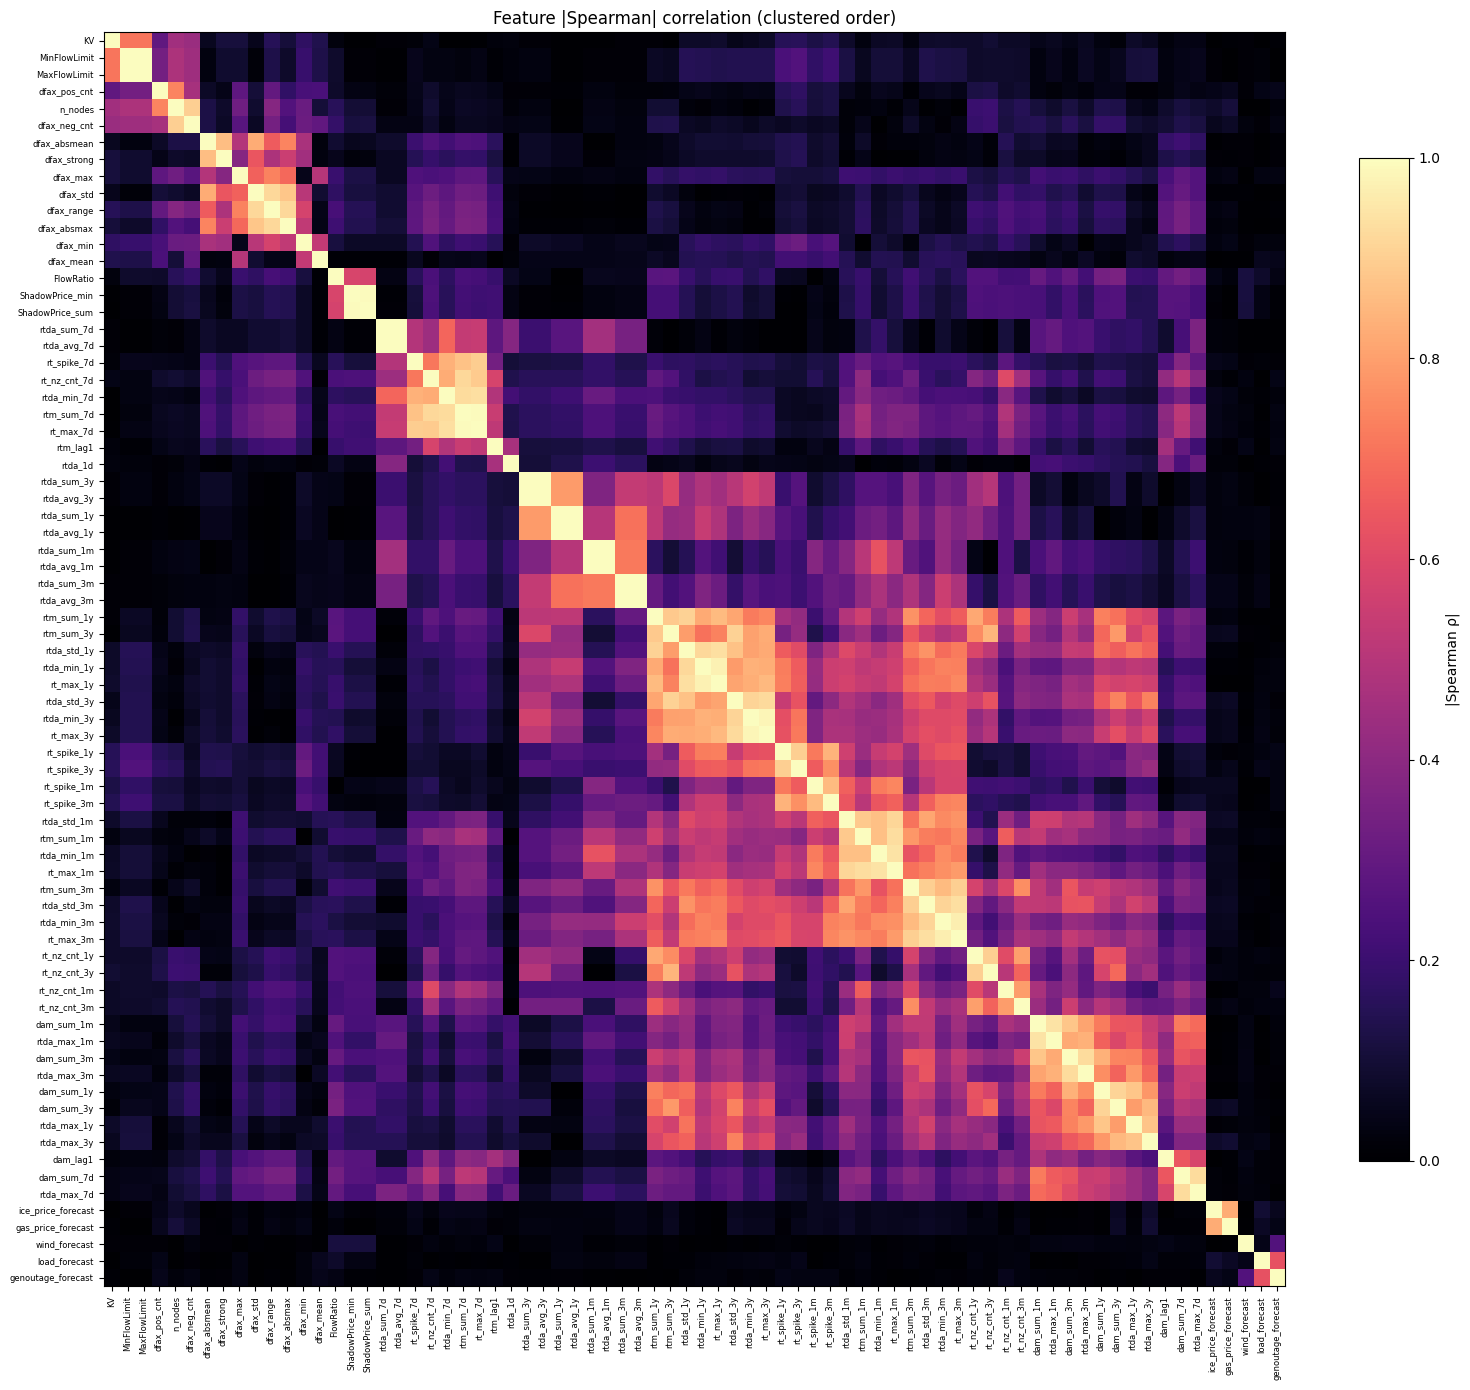

In [92]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import numpy as np

# |Spearman| correlation on the clustering pool
corr_m = train_df_filter[pool].corr('spearman').abs().fillna(0.0)

# order rows/cols by the average-linkage dendrogram so groups form diagonal blocks
d = 1.0 - corr_m.values
np.fill_diagonal(d, 0.0); d = (d + d.T) / 2
Z = linkage(squareform(d, checks=False), method='average')
order = leaves_list(Z)
ordered = corr_m.iloc[order, order]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(ordered.values, cmap='magma', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(ordered))); ax.set_xticklabels(ordered.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(ordered))); ax.set_yticklabels(ordered.index, fontsize=6)
cbar = fig.colorbar(im, ax=ax, shrink=0.8); cbar.set_label('|Spearman ρ|')
ax.set_title('Feature |Spearman| correlation (clustered order)')
plt.tight_layout(); plt.show()


In [93]:
# columns to keep alongside the decorrelated features
keep_extra = ['dt', 'constraint_family_num',          # keys
              'KV_group',                             # categorical driver (not in numeric compact)
              'bad_rtda', 'rt_da', 'rt_da_q', 'rt_da_smaller_500',   # targets / labels
              'short_profit', 'long_profit', 'profit_congestion',    # P&L for analysis
              'monitored_name']                        # id
keep = compact + [c for c in keep_extra if c in train_df_filter.columns and c not in compact]

train_df_filter = train_df_filter[keep].copy()
print(train_df_filter.shape, '| kept:', len(keep), 'cols')
print('dropped:', len(train_df_filter.columns) if False else '',  # see below
      len(set(train_df_filter.columns)))

(134337, 44) | kept: 44 cols
dropped:  44


# bad_rtda rt-da<-3000 classification 

In [62]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, _tree
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter.dropna(subset=['bad_rtda']).copy()   # bad_rtda is 0/1
y = d['bad_rtda'].astype(int)
FEATS = globals().get('compact', features)
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                              # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); pos, N, base = int(y.sum()), len(y), y.mean()
print(f'rows={N}  y=1={pos} ({base*100:.2f}%)')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                          random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=100,
                            class_weight='balanced_subsample', random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

# ---------- 2) readable tree: split + #1s at EACH node ----------
surr = DecisionTreeClassifier(max_depth=4, min_samples_leaf=100, class_weight='balanced',
                              random_state=0).fit(Xn, y)
dp = surr.decision_path(Xn); yv = y.values.astype(bool)
n1 = np.asarray(dp[yv].sum(0)).ravel(); n0 = np.asarray(dp[~yv].sum(0)).ravel()
t = surr.tree_
print('\n=== tree splits: n1 = #(y=1) at node, purity, recall ===')
def show(nd=0, dep=0, br=''):
    tot = n1[nd] + n0[nd]; pur = n1[nd]/tot*100 if tot else 0; rec = n1[nd]/pos*100
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  n1={int(n1[nd]):>4}  purity={pur:4.1f}%  recall={rec:4.1f}%')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by #1s captured (kept from your cell)
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'n_1':int(n1[i]),'n_rows':int(n1[i]+n0[i]),
                      'recall':round(n1[i]/pos*100,1),'purity':round(n1[i]/(n1[i]+n0[i])*100,1),
                      'rule':rules[i]} for i in leaves]).sort_values('n_1',ascending=False).reset_index(drop=True))
tab['cum_recall'] = (tab['n_1'].cumsum()/pos*100).round(1); tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by # of 1s captured ===')
for _, r in tab.iterrows():
    print(f"n_1={int(r['n_1']):>4}  recall={r['recall']:>5}%  purity={r['purity']:>5}%  "
          f"cum_recall={r['cum_recall']:>5}%  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=134337  y=1=2416 (1.80%)

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
rtm_sum_7d,0.1466,0.1148,1.0
rtm_sum_1m,0.0585,0.0766,3.0
rtda_std_3m,0.0374,0.0706,5.0
rt_spike_3y,0.0444,0.0445,6.0
FlowRatio,0.0456,0.0320,7.0
rtm_lag1,0.0338,0.0560,7.5
long_profit_sum_1m,0.0848,0.0174,9.0
rtda_std_1y,0.0275,0.0383,9.5
wind_forecast,0.0372,0.0232,10.5
rt_spike_3m,0.0237,0.0263,11.5



=== tree splits: n1 = #(y=1) at node, purity, recall ===
  [rtm_sum_7d <= -1684.964]  n1=2416  purity= 1.8%  recall=100.0%
    T> [rtda_std_3m <= 701.217]  n1=1658  purity= 5.3%  recall=68.6%
      T> [KV_group <= -0.500]  n1= 316  purity= 2.2%  recall=13.1%
        T> LEAF  n1=  77  purity=67.5%  recall= 3.2%
        F> [rt_spike_3y <= -851.812]  n1= 239  purity= 1.7%  recall= 9.9%
          T> LEAF  n1= 162  purity= 2.7%  recall= 6.7%
          F> LEAF  n1=  77  purity= 0.9%  recall= 3.2%
      F> [KV_group <= -0.500]  n1=1342  purity= 7.9%  recall=55.5%
        T> [dam_lag1 <= -1310.122]  n1= 355  purity=64.7%  recall=14.7%
          T> LEAF  n1=  64  purity=35.4%  recall= 2.6%
          F> LEAF  n1= 291  purity=79.1%  recall=12.0%
        F> [rtm_lag1 <= -0.574]  n1= 987  purity= 6.0%  recall=40.9%
          T> LEAF  n1= 748  purity= 8.7%  recall=31.0%
          F> LEAF  n1= 239  purity= 3.1%  recall= 9.9%
    F> [KV_group <= -0.500]  n1= 758  purity= 0.7%  recall=31.4%
      T> [

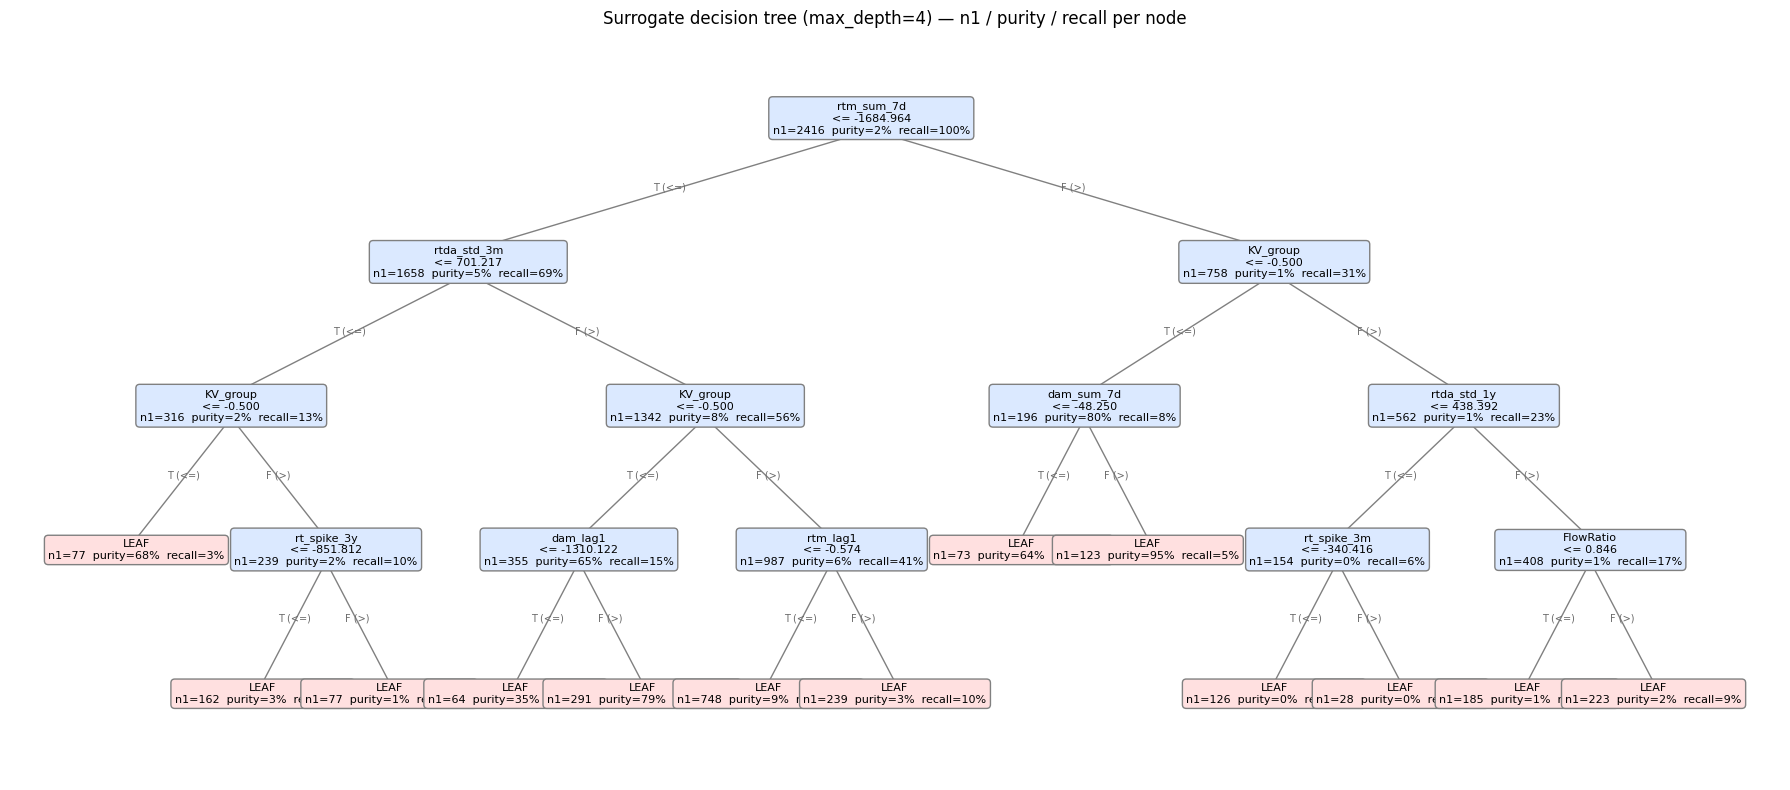

In [63]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y = pos_xy[nd]
    tot = n1[nd] + n0[nd]; pur = n1[nd] / tot * 100 if tot else 0; rec = n1[nd] / pos * 100
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nn1={int(n1[nd])}  purity={pur:.0f}%  recall={rec:.0f}%'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate decision tree (max_depth=4) — n1 / purity / recall per node')
plt.tight_layout()
plt.show()


In [64]:
from sklearn.metrics import (recall_score, precision_score, f1_score, accuracy_score,
                              roc_auc_score, average_precision_score, confusion_matrix)

# ---------- 4) out-of-sample check on holdout_df ----------
dh = holdout_df.query('rtm_sum_1m<-200').dropna(subset=['bad_rtda']).copy()
yh = dh['bad_rtda'].astype(int)
Xc_h = dh[FEATS + CATS].copy()                            # LightGBM: native categoricals + NaN
for c in CATS: Xc_h[c] = Xc_h[c].astype('category')
Xn_h = dh[FEATS + CATS].copy()                             # sklearn: numeric, no NaN
for c in CATS: Xn_h[c] = Xn_h[c].astype('category').cat.codes
Xn_h = Xn_h.fillna(Xn.median())                             # fill with TRAIN medians -> no leakage

pos_h, N_h, base_h = int(yh.sum()), len(yh), yh.mean()
print(f'holdout_df: rows={N_h}  y=1={pos_h} ({base_h*100:.2f}%)')

def eval_model(name, model, X):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(yh, pred).ravel()
    print(f'\n=== {name} on holdout_df ===')
    print(f'  recall={recall_score(yh, pred):.3f}  precision={precision_score(yh, pred):.3f}  '
          f'f1={f1_score(yh, pred):.3f}  accuracy={accuracy_score(yh, pred):.3f}')
    print(f'  roc_auc={roc_auc_score(yh, proba):.3f}  pr_auc={average_precision_score(yh, proba):.3f}')
    print(f'  confusion: tp={tp} fn={fn} fp={fp} tn={tn}')

eval_model('LightGBM', lgbm, Xc_h)
eval_model('RandomForest', rf, Xn_h)


holdout_df: rows=50392  y=1=718 (1.42%)

=== LightGBM on holdout_df ===
  recall=0.471  precision=0.102  f1=0.167  accuracy=0.933
  roc_auc=0.857  pr_auc=0.097
  confusion: tp=338 fn=380 fp=2989 tn=46685

=== RandomForest on holdout_df ===
  recall=0.547  precision=0.090  f1=0.155  accuracy=0.915
  roc_auc=0.859  pr_auc=0.143
  confusion: tp=393 fn=325 fp=3955 tn=45719


# Pinball loss on the rt-da 

In [94]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = globals().get('compact', features)
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=134337  rt_da mean=-88.4  median=0.0  p1=-4525.8  p5=-813.4

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=80.79

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
rtm_sum_7d,0.1607
dfax_absmax,0.0717
FlowRatio,0.0706
rt_spike_3y,0.0587
rtda_std_1y,0.0412
rt_nz_cnt_1y,0.0410
rtda_avg_3y,0.0365
rtm_lag1,0.0346
rtm_sum_1m,0.0340
rt_spike_3m,0.0317



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.046


In [95]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [KV_group <= -0.500]  mean=     -88.4  n_rows=134337
    T> [dam_lag1 <= -0.778]  mean=   -4439.4  n_rows=  907
      T> [dam_lag1 <= -3783.386]  mean=   -2561.2  n_rows=  400
        T> LEAF  mean=   -1001.1  n_rows=  112
        F> [rt_nz_cnt_1y <= 70.500]  mean=   -3167.9  n_rows=  288
          T> LEAF  mean=   -4006.3  n_rows=  145
          F> LEAF  mean=   -2317.7  n_rows=  143
      F> [rtda_avg_1m <= -1063.088]  mean=   -5921.2  n_rows=  507
        T> LEAF  mean=   -8015.0  n_rows=  123
        F> [dam_sum_7d <= -51.753]  mean=   -5250.6  n_rows=  384
          T> LEAF  mean=   -4473.8  n_rows=  147
          F> LEAF  mean=   -5732.4  n_rows=  237
    F> [rtda_avg_7d <= -5714.757]  mean=     -58.9  n_rows=133430
      T> LEAF  mean=   -2736.4  n_rows=  143
      F> [rtda_avg_7d <= -152.957]  mean=     -56.0  n_rows=133287
        T> [rtda_avg_3m <= -529.519]  mean=    -205.5  n_rows=25001
          T> LEAF  mean=    -77

In [96]:
train_df.KV_group.unique()

array(['04_345', '03_138', '02_<=115', '05_>=500', nan], dtype=object)

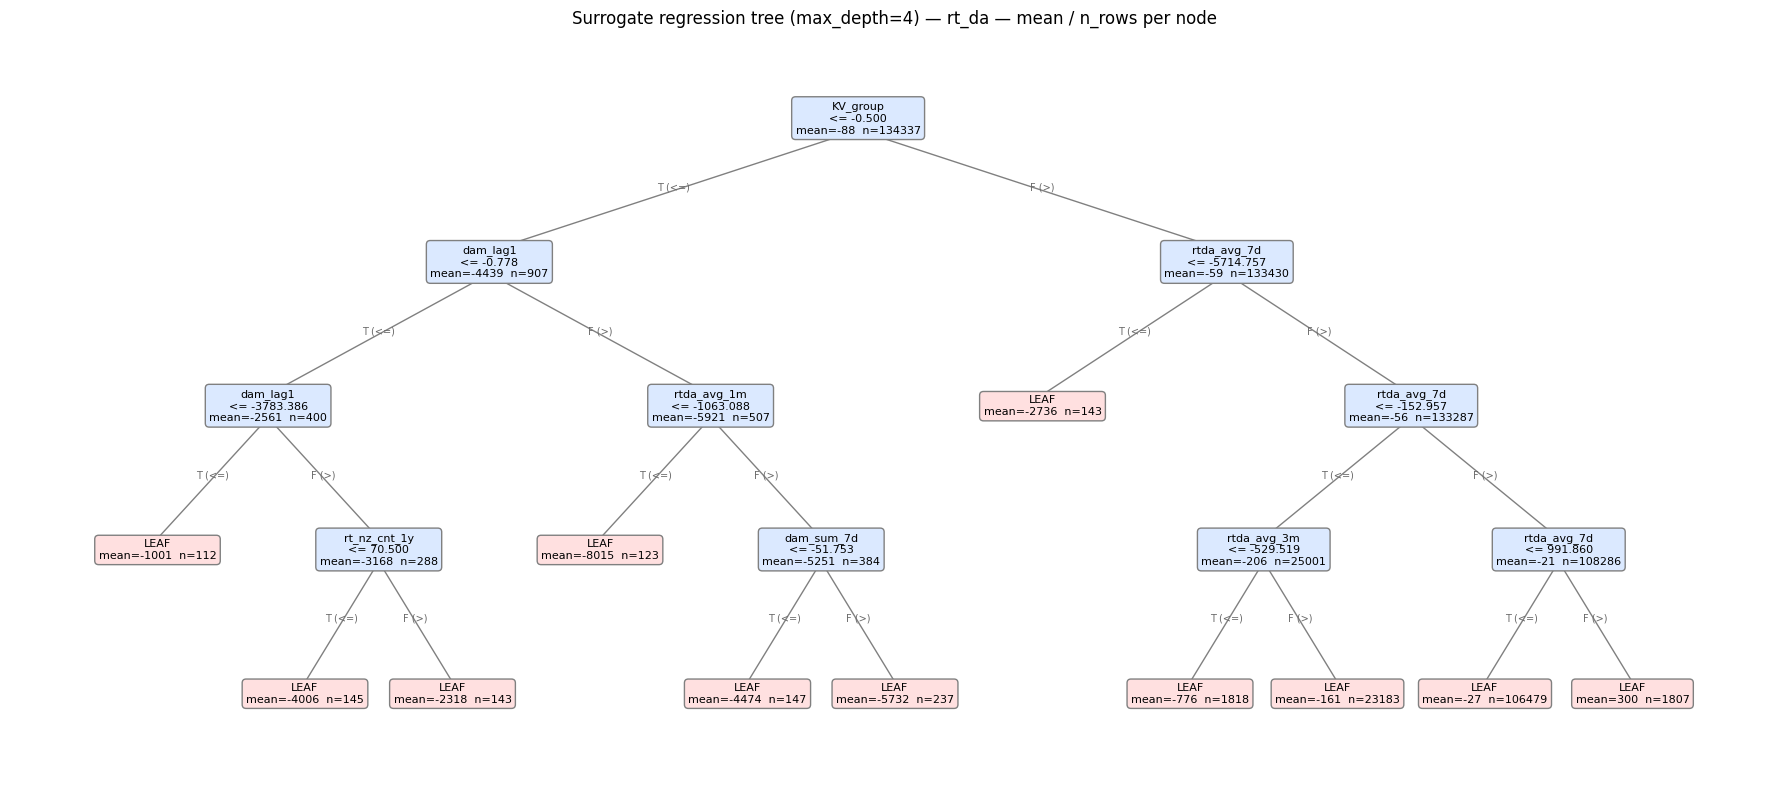

In [97]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da — mean / n_rows per node')
plt.tight_layout()
plt.show()


# rerun without top variable 

In [98]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f not in (['rtm_sum_7d','rtda_sum_7d','rtm_sum_3m','rtda_avg_7d','rt_max_3m', 'long_profit_sum_1m','short_profit_sum_1m'])]
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=134337  rt_da mean=-88.4  median=0.0  p1=-4525.8  p5=-813.4

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=80.67

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
dfax_absmax,0.1029
rtm_lag1,0.0668
FlowRatio,0.0639
rtm_sum_1m,0.0623
rt_nz_cnt_1m,0.0601
dfax_absmean,0.0442
wind_forecast,0.0418
rtda_std_1y,0.0389
rt_nz_cnt_1y,0.0367
rt_spike_3m,0.0362



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.045


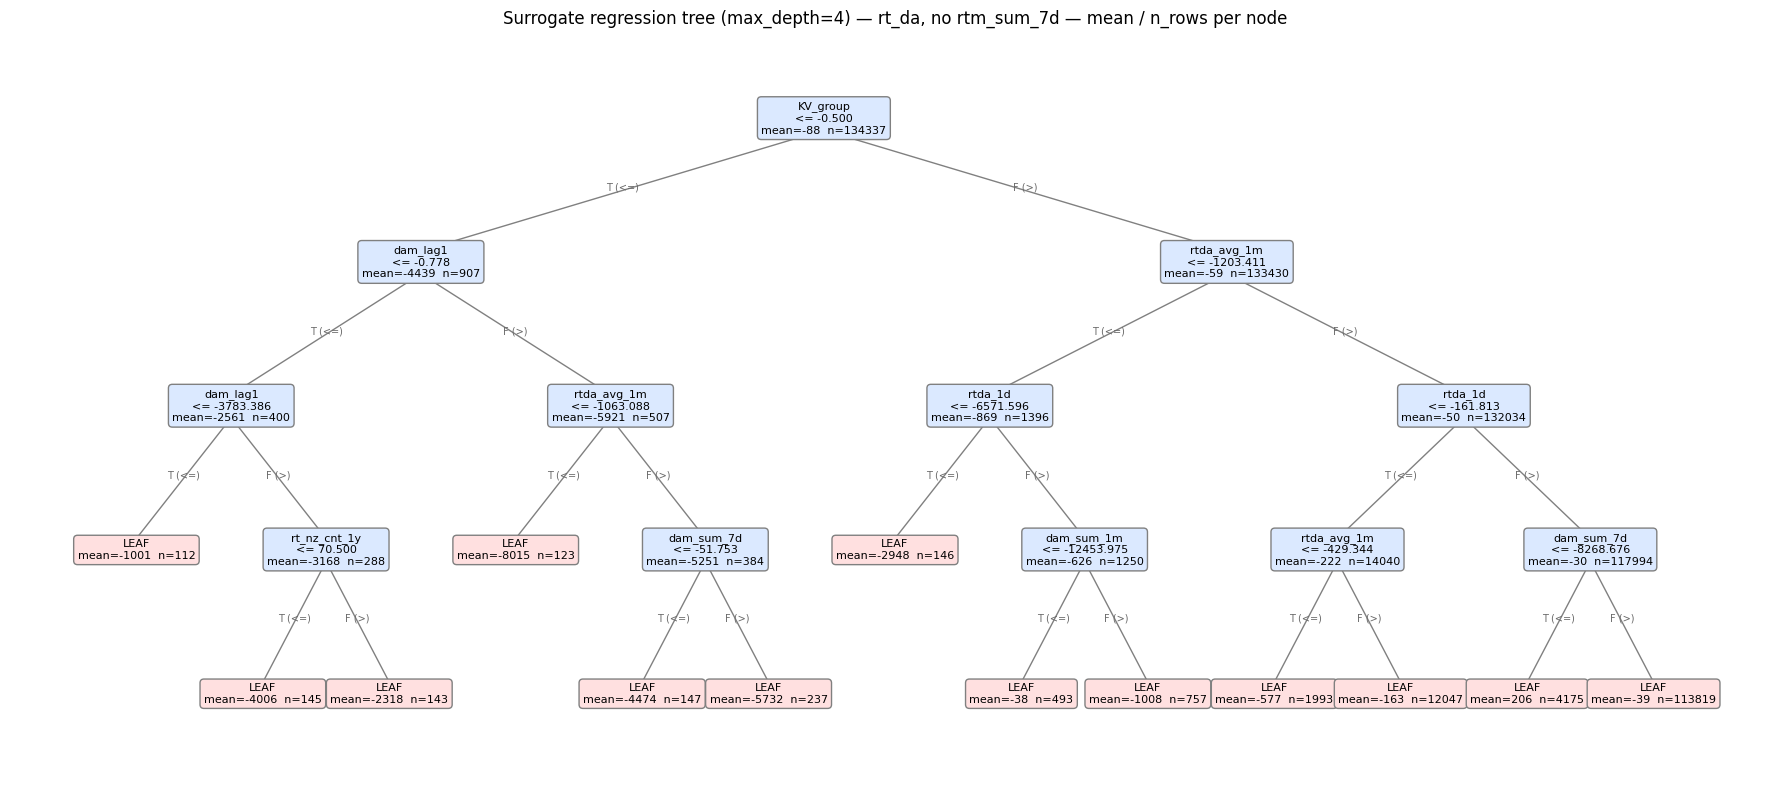

In [99]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- fit the surrogate tree on THIS section's d/y/FEATS (no rtm_sum_7d) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, no rtm_sum_7d — mean / n_rows per node')
plt.tight_layout()
plt.show()


In [89]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [KV_group <= -0.500]  mean=     -88.4  n_rows=134337
    T> [dam_lag1 <= -0.778]  mean=   -4439.4  n_rows=  907
      T> [dam_lag1 <= -3783.386]  mean=   -2561.2  n_rows=  400
        T> LEAF  mean=   -1001.1  n_rows=  112
        F> [rt_nz_cnt_1y <= 70.500]  mean=   -3167.9  n_rows=  288
          T> LEAF  mean=   -4006.3  n_rows=  145
          F> LEAF  mean=   -2317.7  n_rows=  143
      F> [rtda_avg_1m <= -1063.088]  mean=   -5921.2  n_rows=  507
        T> LEAF  mean=   -8015.0  n_rows=  123
        F> [dam_sum_7d <= -51.753]  mean=   -5250.6  n_rows=  384
          T> LEAF  mean=   -4473.8  n_rows=  147
          F> LEAF  mean=   -5732.4  n_rows=  237
    F> [rtda_avg_1m <= -1203.411]  mean=     -58.9  n_rows=133430
      T> [rtda_1d <= -6571.596]  mean=    -868.5  n_rows= 1396
        T> LEAF  mean=   -2948.2  n_rows=  146
        F> [dam_sum_1m <= -12453.975]  mean=    -625.6  n_rows= 1250
          T> LEAF  mean=     -38

# Rerun with selected variables: KV, FlowRatio, rtm_sum_7d, dam_sum_7d, rt_da_std_1m

In [100]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f  in (['rtm_sum_7d','rtm_sum_3m','rtm_lag1','FlowRatio'])]
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=134337  rt_da mean=-88.4  median=0.0  p1=-4525.8  p5=-813.4

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=96.18

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
rtm_sum_7d,0.4173
FlowRatio,0.2348
KV_group,0.2128
rtm_lag1,0.1351



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.043


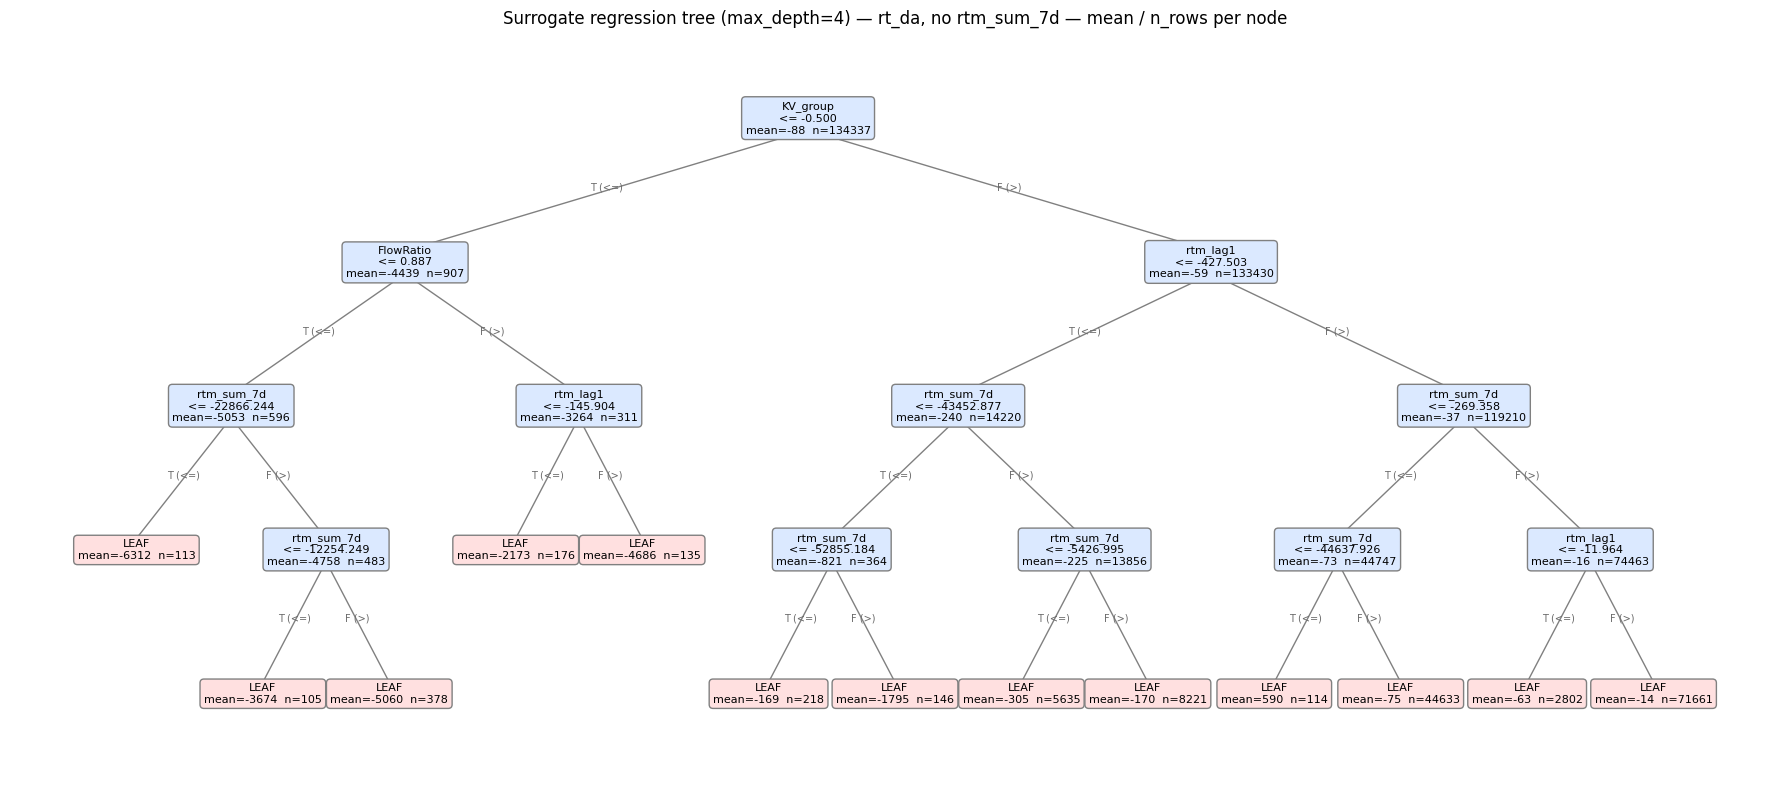

In [101]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- fit the surrogate tree on THIS section's d/y/FEATS (no rtm_sum_7d) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, no rtm_sum_7d — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Setting quantile to split the variables to see the rate of capturing. 

In [105]:
d = train_df_filter.dropna(subset=['rt_da', 'FlowRatio']).copy()

# 10 equal-count FlowRatio buckets
d['FlowRatio_q'] = pd.qcut(d['FlowRatio'], q=10, duplicates='drop')

bucket = (d.groupby('FlowRatio_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'))
            .round(2))
display(bucket)


,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda
FlowRatio_q,,,,,,,
"(-0.001, 0.285]",11479,0.00,0.29,-82.81,0.0,-360.88,129
"(0.285, 0.419]",11478,0.29,0.42,-85.62,0.0,-330.07,121
"(0.419, 0.52]",11479,0.42,0.52,-60.87,0.0,-197.26,97
"(0.52, 0.604]",11478,0.52,0.60,-65.16,0.0,-273.82,106
"(0.604, 0.683]",11479,0.60,0.68,-77.35,0.0,-325.45,148
"(0.683, 0.762]",11479,0.68,0.76,-75.14,0.0,-497.08,168
"(0.762, 0.845]",11477,0.76,0.84,-90.93,0.0,-739.22,191
"(0.845, 0.936]",11479,0.84,0.94,-108.13,0.0,-1181.07,269
"(0.936, 1.0]",18931,0.94,1.00,-91.06,0.0,-1918.91,599


In [109]:
d = train_df_filter.dropna(subset=['rt_da', 'rtm_sum_7d']).copy()

# 10 equal-count FlowRatio buckets
d['rtm_sum_7d_q'] = pd.qcut(d['rtm_sum_7d'], q=10, duplicates='drop')

bucket = (d.groupby('rtm_sum_7d_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'))
            .round(2))
display(bucket)


,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda
rtm_sum_7d_q,,,,,,,
"(-130256.945, -5339.41]",13434,0.0,1.64,-354.43,0.0,-4743.71,1154
"(-5339.41, -2189.678]",13436,0.0,1.63,-163.22,0.0,-1937.79,406
"(-2189.678, -997.262]",13435,0.0,1.56,-117.37,0.0,-1145.08,241
"(-997.262, -426.971]",13430,0.0,1.58,-79.06,0.0,-720.43,150
"(-426.971, -114.478]",13435,0.0,1.73,-61.77,0.0,-449.63,127
"(-114.478, 0.0]",67167,0.0,1.67,-21.69,0.0,-29.09,338


In [108]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.tree import DecisionTreeRegressor, _tree
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

# rows NOT captured by the top cut
d = train_df_filter.query('rtm_sum_7d > -9622').dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)

# drop rtm_sum_7d itself (near-constant / already used) + long/short profit handled upstream
FEATS = [f for f in globals().get('compact', features) if f != 'rtm_sum_7d']
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  '
      f'p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# ---------- feature importance (tau=0.05 quantile model) ----------
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
m = lgb.LGBMRegressor(objective='quantile', alpha=0.05, n_estimators=400, learning_rate=0.05,
                      num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                      random_state=0, n_jobs=-1, verbose=-1).fit(X, y, categorical_feature=CATS)
imp = pd.Series(m.booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05, subset rtm_sum_7d > -9622 ===')
display(imp.head(15).round(4).to_frame('gain'))

# ---------- surrogate tree: mean rt_da / n_rows at each node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_; node_mean = t.value[:, 0, 0]; node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>6}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> '); show(t.children_right[nd], dep+1, 'F> ')
show()

# ---------- leaf rules ranked by worst mean rt_da ----------
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),'rule':rules[i]} for i in leaves])
       .sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>6}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=127285  rt_da mean=-69.0  median=0.0  p1=-3499.4  p5=-573.6

=== feature importance (gain) — tau=0.05, subset rtm_sum_7d > -9622 ===


,gain
dfax_absmax,0.0825
rtda_avg_7d,0.0814
FlowRatio,0.0751
rtda_std_1y,0.0457
rtm_lag1,0.0456
dam_sum_7d,0.0407
rtm_sum_1m,0.0404
rt_nz_cnt_1y,0.0404
rt_spike_3m,0.0396
rt_spike_3y,0.0392



=== tree splits: mean rt_da / n_rows at EACH node ===
  [KV_group <= -0.500]  mean=     -69.0  n_rows=127285
    T> [dam_sum_7d <= -51.753]  mean=   -4438.3  n_rows=   527
      T> [rtm_lag1 <= -153.066]  mean=   -3453.0  n_rows=   306
        T> LEAF  mean=   -2433.2  n_rows=   141
        F> LEAF  mean=   -4324.4  n_rows=   165
      F> [rtda_avg_7d <= -125.957]  mean=   -5802.6  n_rows=   221
        T> LEAF  mean=   -6532.5  n_rows=   109
        F> LEAF  mean=   -5092.3  n_rows=   112
    F> [rtda_avg_7d <= -152.957]  mean=     -50.9  n_rows=126758
      T> [rtda_avg_1m <= -247.654]  mean=    -199.7  n_rows= 19913
        T> [rtda_1d <= -73.231]  mean=    -399.2  n_rows=  5153
          T> LEAF  mean=    -590.6  n_rows=  2110
          F> LEAF  mean=    -266.5  n_rows=  3043
        F> [rtda_avg_1m <= 438.592]  mean=    -130.0  n_rows= 14760
          T> LEAF  mean=    -121.6  n_rows= 14658
          F> LEAF  mean=   -1341.4  n_rows=   102
      F> [rtda_avg_3m <= 57.363]  mean= 

# Profit Congestion model 


In [106]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, _tree
from sklearn.metrics import r2_score, mean_absolute_error
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter.query('profit_congestion < 0').dropna(subset=['profit_congestion']).copy()
y = d['profit_congestion'].astype(float)
FEATS = globals().get('compact', features) 
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                               # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); N = len(y)
print(f'rows={N}  profit_congestion mean={y.mean():.1f}  median={y.median():.1f}  p5={y.quantile(.05):.1f}')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=100,
                           random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

print('\n=== in-sample fit ===')
for name, m, X in (('LightGBM', lgbm, Xc), ('RandomForest', rf, Xn)):
    p = m.predict(X)
    print(f'  {name:<13} R2={r2_score(y, p):.3f}  MAE={mean_absolute_error(y, p):.1f}')

# ---------- 2) readable tree: split + node stats at EACH node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean profit_congestion / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean profit_congestion
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by worst mean profit_congestion ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=30950  profit_congestion mean=-9557.0  median=-2572.9  p5=-36770.9

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
wind_forecast,0.2161,0.3398,1.5
load_forecast,0.3019,0.1884,2.0
genoutage_forecast,0.1558,0.0810,3.5
dfax_neg_cnt,0.0830,0.2515,3.5
ice_price_forecast,0.1092,0.0612,4.5
dfax_pos_cnt,0.0292,0.0522,6.0
MaxFlowLimit,0.0087,0.0026,7.0
dfax_absmax,0.0068,0.0013,10.5
rt_spike_3y,0.0057,0.0020,10.5
FlowRatio,0.0074,0.0012,10.5



=== in-sample fit ===
  LightGBM      R2=0.768  MAE=5778.2
  RandomForest  R2=0.240  MAE=8700.2

=== tree splits: mean profit_congestion / n_rows at EACH node ===
  [dfax_neg_cnt <= 26.500]  mean=   -9557.0  n_rows=30950
    T> [dfax_pos_cnt <= 9.500]  mean=   -6493.6  n_rows=23308
      T> [dfax_neg_cnt <= 5.500]  mean=   -4587.0  n_rows=15250
        T> [dfax_pos_cnt <= 5.500]  mean=   -2864.8  n_rows= 7621
          T> LEAF  mean=   -2136.3  n_rows= 5843
          F> LEAF  mean=   -5258.8  n_rows= 1778
        F> [wind_forecast <= 14243.030]  mean=   -6307.4  n_rows= 7629
          T> LEAF  mean=   -4961.1  n_rows= 4326
          F> LEAF  mean=   -8070.6  n_rows= 3303
      F> [wind_forecast <= 14160.580]  mean=  -10101.8  n_rows= 8058
        T> [ice_price_forecast <= 32.155]  mean=   -7943.9  n_rows= 4609
          T> LEAF  mean=  -10475.7  n_rows= 1775
          F> LEAF  mean=   -6358.1  n_rows= 2834
        F> [dfax_neg_cnt <= 9.500]  mean=  -12985.4  n_rows= 3449
          T> 

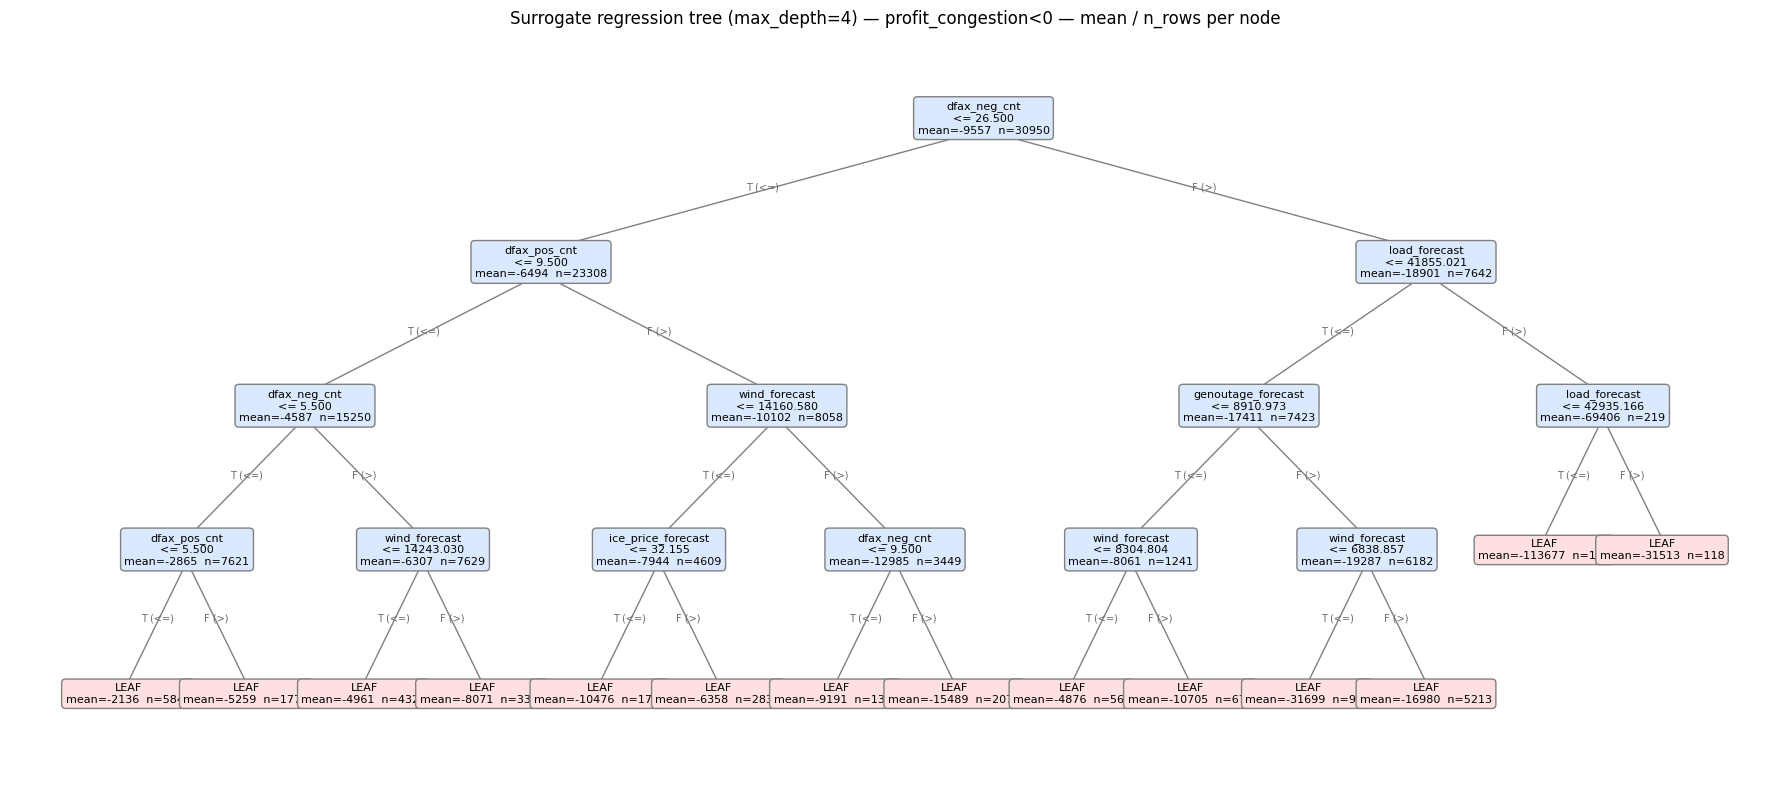

In [107]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — profit_congestion<0 — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Rerun without the top variables

In [44]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, _tree
from sklearn.metrics import r2_score, mean_absolute_error
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter.query('profit_congestion < 0').dropna(subset=['profit_congestion']).copy()
y = d['profit_congestion'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f not in ('dfax_pos_cnt', 'dfax_neg_cnt', 'load_forecast','wind_forecast','genoutage_forecast','ice_price_forecast')]
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                               # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); N = len(y)
print(f'rows={N}  profit_congestion mean={y.mean():.1f}  median={y.median():.1f}  p5={y.quantile(.05):.1f}')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=100,
                           random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

print('\n=== in-sample fit ===')
for name, m, X in (('LightGBM', lgbm, Xc), ('RandomForest', rf, Xn)):
    p = m.predict(X)
    print(f'  {name:<13} R2={r2_score(y, p):.3f}  MAE={mean_absolute_error(y, p):.1f}')

# ---------- 2) readable tree: split + node stats at EACH node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean profit_congestion / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean profit_congestion
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by worst mean profit_congestion ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=30950  profit_congestion mean=-9557.0  median=-2572.9  p5=-36770.9

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
MaxFlowLimit,0.0718,0.1576,1.0
dfax_max,0.0573,0.1256,2.0
dfax_absmean,0.0520,0.0715,3.0
long_profit_sum_1m,0.0375,0.0513,5.0
dfax_mean,0.0419,0.0443,6.0
dfax_min,0.0356,0.0486,7.0
FlowRatio,0.0432,0.0284,8.0
rt_spike_1y,0.0358,0.0315,9.5
dfax_absmax,0.0316,0.0359,10.0
short_profit_sum_1y,0.0311,0.0386,10.0



=== in-sample fit ===
  LightGBM      R2=0.359  MAE=8551.3
  RandomForest  R2=0.105  MAE=9695.6

=== tree splits: mean profit_congestion / n_rows at EACH node ===
  [MaxFlowLimit <= 286.900]  mean=   -9557.0  n_rows=30950
    T> [dfax_max <= 0.745]  mean=   -7711.1  n_rows=22670
      T> [dfax_max <= 0.025]  mean=   -7506.9  n_rows=22366
        T> [dfax_max <= -0.010]  mean=   -4961.4  n_rows= 6441
          T> LEAF  mean=   -3014.5  n_rows= 2168
          F> LEAF  mean=   -5949.1  n_rows= 4273
        F> [dfax_absmean <= 0.062]  mean=   -8536.5  n_rows=15925
          T> LEAF  mean=   -9977.6  n_rows=10355
          F> LEAF  mean=   -5857.5  n_rows= 5570
      F> [rt_nz_cnt_1y <= 105.500]  mean=  -22728.2  n_rows=  304
        T> [dfax_min <= -0.057]  mean=  -15037.7  n_rows=  202
          T> LEAF  mean=  -20234.1  n_rows=  100
          F> LEAF  mean=   -9943.3  n_rows=  102
        F> LEAF  mean=  -37958.3  n_rows=  102
    F> [KV <= 287.500]  mean=  -14611.2  n_rows= 8280
      

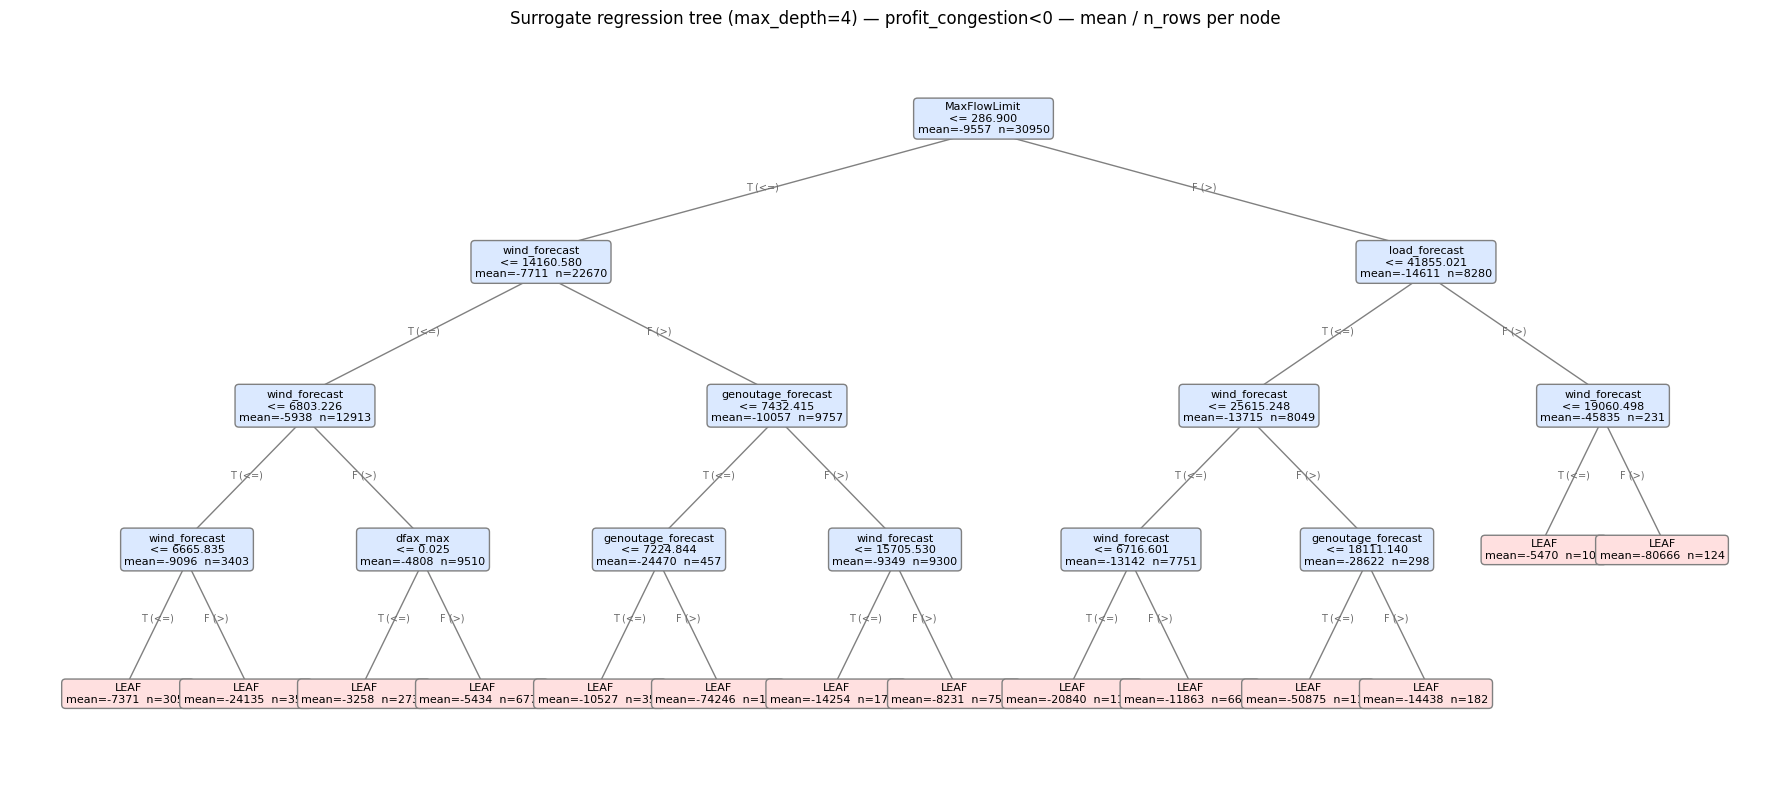

In [36]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — profit_congestion<0 — mean / n_rows per node')
plt.tight_layout()
plt.show()


In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# ---------- out-of-sample check on holdout_df ----------
dh = (holdout_df.query('rtm_sum_1m<-200 and profit_congestion < 0')
      .dropna(subset=['profit_congestion']).copy())
yh = dh['profit_congestion'].astype(float)
Xc_h = dh[FEATS + CATS].copy()                            # LightGBM: native categoricals + NaN
for c in CATS: Xc_h[c] = Xc_h[c].astype('category')
Xn_h = dh[FEATS + CATS].copy()                             # sklearn: numeric, no NaN
for c in CATS: Xn_h[c] = Xn_h[c].astype('category').cat.codes
Xn_h = Xn_h.fillna(Xn.median())                             # fill with TRAIN medians -> no leakage

print(f'holdout_df: rows={len(yh)}  profit_congestion mean={yh.mean():.1f}  median={yh.median():.1f}')

def eval_model(name, model, X):
    pred = model.predict(X)
    print(f'\n=== {name} on holdout_df ===')
    print(f'  R2={r2_score(yh, pred):.3f}  MAE={mean_absolute_error(yh, pred):.1f}  '
          f'RMSE={root_mean_squared_error(yh, pred):.1f}')

eval_model('LightGBM', lgbm, Xc_h)
eval_model('RandomForest', rf, Xn_h)


holdout_df: rows=11307  profit_congestion mean=-8229.2  median=-2461.9

=== LightGBM on holdout_df ===
  R2=-0.151  MAE=9098.5  RMSE=16610.2

=== RandomForest on holdout_df ===
  R2=-0.038  MAE=9119.6  RMSE=15773.8


# Break down by KV and train model separately 

In [55]:
from sklearn.tree import DecisionTreeRegressor, _tree
FEATS = [c for c in globals().get('compact', features) if c not in ('KV','KV_group')]
sev = lambda g: ((g['rt_da'] < -3000) & (g['short_profit'] < -400000) & (g['profit_congestion'] < 0)).astype(int)

def kv_tree(g, grp):
    y = sev(g); Xt = g[FEATS]
    surr = DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=0).fit(Xt, y)
    imp = pd.Series(surr.feature_importances_, index=FEATS).sort_values(ascending=False)
    dp = surr.decision_path(Xt); yv = y.values
    n1 = np.asarray(dp[yv==1].sum(0)).ravel(); n0 = np.asarray(dp[yv==0].sum(0)).ravel()
    t, TOT1, ft = surr.tree_, int(yv.sum()), list(Xt.columns)
    print(f'\n== KV_group={grp}  rows={len(g)}  pos={TOT1}  base={yv.mean()*100:.2f}% ==')
    print('  top:', {k: round(v,2) for k,v in imp.head(5).items() if v>0})
    def show(n=0,d=0,b=''):
        tot=n1[n]+n0[n]; pur=n1[n]/tot*100 if tot else 0; rec=n1[n]/TOT1*100 if TOT1 else 0
        lab='LEAF' if t.feature[n]==_tree.TREE_UNDEFINED else f'[{ft[t.feature[n]]} <= {t.threshold[n]:.2f}]'
        print(f'  {"  "*d}{b}{lab}  pur={pur:4.1f}%  n1={int(n1[n])}  rec={rec:4.1f}%')
        if t.feature[n]!=_tree.TREE_UNDEFINED: show(t.children_left[n],d+1,'T>'); show(t.children_right[n],d+1,'F>')
    show()

for grp, g in train_df_filter.groupby('KV_group'):
    if len(g) >= 500 and g['bad_rtda'].sum() >= 30: kv_tree(g, grp)
    else: print(f'\n== KV_group={grp}: too few (rows={len(g)}, pos={int(g.bad_rtda.sum())}) ==')

interested = train_df.query('rt_da < -3000 and short_profit<-400000 and profit_congestion < 0')


== KV_group=02_<=115  rows=29176  pos=12  base=0.04% ==
  top: {'long_profit_sum_1y': 0.48, 'FlowRatio': 0.36, 'short_profit_sum_1m': 0.16}
  [long_profit_sum_1y <= -3566199.38]  pur= 0.0%  n1=12  rec=100.0%
    T>LEAF  pur= 1.8%  n1=3  rec=25.0%
    F>[FlowRatio <= 1.17]  pur= 0.0%  n1=9  rec=75.0%
      T>[short_profit_sum_1m <= -1238948.50]  pur= 0.0%  n1=7  rec=58.3%
        T>LEAF  pur= 1.0%  n1=2  rec=16.7%
        F>LEAF  pur= 0.0%  n1=5  rec=41.7%
      F>LEAF  pur= 0.2%  n1=2  rec=16.7%

== KV_group=03_138  rows=45283  pos=36  base=0.08% ==
  top: {'dfax_absmax': 0.39, 'wind_forecast': 0.31, 'dam_sum_1m': 0.14, 'rtm_lag1': 0.07, 'short_profit_sum_1m': 0.05}
  [dam_sum_1m <= -14818.62]  pur= 0.1%  n1=36  rec=100.0%
    T>[dfax_absmax <= 0.73]  pur= 0.5%  n1=28  rec=77.8%
      T>[rtm_lag1 <= -7329.06]  pur= 0.3%  n1=19  rec=52.8%
        T>LEAF  pur= 1.8%  n1=5  rec=13.9%
        F>LEAF  pur= 0.3%  n1=14  rec=38.9%
      F>[wind_forecast <= 14374.49]  pur= 4.4%  n1=9  rec=25.0

In [56]:
from sklearn.tree import DecisionTreeRegressor, _tree
FEATS = [c for c in globals().get('compact', features) if c not in ('KV','KV_group','rtm_sum_7d')]  # drop split var

def seg_tree(g, name):
    y = g['bad_rtda']; Xt = g[FEATS]
    surr = DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=0).fit(Xt, y)
    imp = pd.Series(surr.feature_importances_, index=FEATS).sort_values(ascending=False)
    dp = surr.decision_path(Xt); yv = y.values
    n1 = np.asarray(dp[yv==1].sum(0)).ravel(); n0 = np.asarray(dp[yv==0].sum(0)).ravel()
    t, TOT1, ft = surr.tree_, int(yv.sum()), list(Xt.columns)
    print(f'\n== {name}  rows={len(g):,}  pos={TOT1}  base={yv.mean()*100:.2f}% ==')
    print('  top:', {k: round(v,2) for k,v in imp.head(5).items() if v>0})
    def show(n=0,dep=0,b=''):
        tot=n1[n]+n0[n]; pur=n1[n]/tot*100 if tot else 0; rec=n1[n]/TOT1*100 if TOT1 else 0
        lab='LEAF' if t.feature[n]==_tree.TREE_UNDEFINED else f'[{ft[t.feature[n]]} <= {t.threshold[n]:.2f}]'
        print(f'  {"  "*dep}{b}{lab}  pur={pur:4.1f}%  n1={int(n1[n])}  tot={int(tot)}  rec={rec:4.1f}%')
        if t.feature[n]!=_tree.TREE_UNDEFINED: show(t.children_left[n],dep+1,'T>'); show(t.children_right[n],dep+1,'F>')
    show()

m = train_df_filter['rtm_sum_7d'] <= -15000
seg_tree(train_df_filter[m],  'rtm_sum_7d <= -15000')
seg_tree(train_df_filter[~m], 'rtm_sum_7d >  -15000')



== rtm_sum_7d <= -15000  rows=3,612  pos=389  base=10.77% ==
  top: {'rtda_1d': 0.37, 'rtda_sum_1y': 0.25, 'wind_forecast': 0.14, 'rtda_avg_3m': 0.09, 'ice_price_forecast': 0.09}
  [rtda_1d <= -2797.83]  pur=10.8%  n1=389  tot=3612  rec=100.0%
    T>[rtda_sum_1y <= -109140.14]  pur=19.8%  n1=162  tot=818  rec=41.6%
      T>[rtda_sum_7d <= -21549.29]  pur=32.6%  n1=71  tot=218  rec=18.3%
        T>LEAF  pur=41.2%  n1=42  tot=102  rec=10.8%
        F>LEAF  pur=25.0%  n1=29  tot=116  rec= 7.5%
      F>[ice_price_forecast <= 74.27]  pur=15.2%  n1=91  tot=600  rec=23.4%
        T>LEAF  pur=12.2%  n1=59  tot=482  rec=15.2%
        F>LEAF  pur=27.1%  n1=32  tot=118  rec= 8.2%
    F>[wind_forecast <= 14518.42]  pur= 8.1%  n1=227  tot=2794  rec=58.4%
      T>[rtda_sum_1y <= -39188.56]  pur= 5.2%  n1=82  tot=1583  rec=21.1%
        T>LEAF  pur= 7.8%  n1=60  tot=765  rec=15.4%
        F>LEAF  pur= 2.7%  n1=22  tot=818  rec= 5.7%
      F>[rtda_avg_3m <= -477.19]  pur=12.0%  n1=145  tot=1211  rec=

# Extreme rt_da tail on full train_df — how good is FlowRatio vs other drivers


In [27]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = globals().get('compact', features)
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  '
      f'p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the extreme LEFT tail (smallest / most negative rt_da) since that's the risk side
TAUS = [0.01, 0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample, full train_df) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.01 model (the most extreme tail)
imp = pd.Series(models[0.01].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.01 quantile model (most extreme tail) ===')
display(imp.head(15).round(4).to_frame('gain'))
fr_rank = list(imp.index).index('FlowRatio') + 1 if 'FlowRatio' in imp.index else None
print(f"\nFlowRatio rank: {fr_rank} of {len(imp)}   gain={imp.get('FlowRatio', float('nan')):.4f}")

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=133430  rt_da mean=-58.9  median=0.0  p1=-3656.6  p5=-676.7

=== pinball loss by quantile (in-sample, full train_df) ===
  tau=0.01  pinball_loss=22.17
  tau=0.05  pinball_loss=75.70

=== feature importance (gain) — tau=0.01 quantile model (most extreme tail) ===


,gain
rtm_lag1,0.0502
wind_forecast,0.0469
FlowRatio,0.0364
rtm_sum_7d,0.0249
ice_price_forecast,0.0214
gas_price_forecast,0.0207
rtm_sum_1m,0.0188
load_forecast,0.0186
rt_spike_3y,0.0182
dfax_std,0.0176



FlowRatio rank: 3 of 85   gain=0.0364

=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.01  target=0.01  actual_coverage=0.007
  tau=0.05  target=0.05  actual_coverage=0.046


In [28]:
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.metrics import mean_pinball_loss

# ---------- how good is FlowRatio alone at the extreme tail? ----------
tail_taus = [0.01, 0.05]

rho_all, p_all = spearmanr(d['FlowRatio'], y)
print(f'Spearman(FlowRatio, rt_da) overall: rho={rho_all:.3f}  p={p_all:.1e}')

for tau in tail_taus:
    thr = y.quantile(tau)
    in_tail = y <= thr
    rho_t, p_t = spearmanr(d.loc[in_tail, 'FlowRatio'], y[in_tail])
    print(f'  within bottom {tau*100:.0f}% (rt_da <= {thr:.1f}, n={int(in_tail.sum())}): '
          f'Spearman(FlowRatio, rt_da) rho={rho_t:.3f}  p={p_t:.1e}')

# single-feature quantile model: FlowRatio ONLY, vs the full multivariate model, at the same taus
Xf = d[['FlowRatio']].copy()
print('\n=== FlowRatio-only vs full-feature quantile model: pinball loss ===')
for tau in tail_taus:
    mf = lgb.LGBMRegressor(objective='quantile', alpha=tau, n_estimators=400, learning_rate=0.05,
                           num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                           random_state=0, n_jobs=-1, verbose=-1).fit(Xf, y)
    pf = mf.predict(Xf)
    loss_flowratio_only = mean_pinball_loss(y, pf, alpha=tau)
    loss_full = scores[tau]
    gain_pct = (loss_flowratio_only - loss_full) / loss_flowratio_only * 100
    print(f'  tau={tau:<5} FlowRatio-only={loss_flowratio_only:.2f}   full-model={loss_full:.2f}   '
          f'gain_from_others={gain_pct:.1f}%')


Spearman(FlowRatio, rt_da) overall: rho=nan  p=nan
  within bottom 1% (rt_da <= -3656.6, n=1335): Spearman(FlowRatio, rt_da) rho=nan  p=nan
  within bottom 5% (rt_da <= -676.7, n=6672): Spearman(FlowRatio, rt_da) rho=nan  p=nan

=== FlowRatio-only vs full-feature quantile model: pinball loss ===
  tau=0.01  FlowRatio-only=60.84   full-model=22.17   gain_from_others=63.6%
  tau=0.05  FlowRatio-only=119.68   full-model=75.70   gain_from_others=36.7%


In [30]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da (full train_df) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [rtda_sum_7d <= -40003.303]  mean=     -58.9  n_rows=133430
    T> LEAF  mean=   -2736.4  n_rows=  143
    F> [rtda_sum_7d <= -1070.702]  mean=     -56.0  n_rows=133287
      T> [rtda_sum_3m <= -47656.691]  mean=    -205.5  n_rows=25001
        T> [rt_max_3m <= -15122.946]  mean=    -775.6  n_rows= 1818
          T> LEAF  mean=    -343.8  n_rows=  721
          F> LEAF  mean=   -1059.4  n_rows= 1097
        F> [rtm_sum_7d <= -51504.768]  mean=    -160.8  n_rows=23183
          T> LEAF  mean=    2166.2  n_rows=  100
          F> LEAF  mean=    -170.9  n_rows=23083
      F> [rtda_avg_7d <= 991.860]  mean=     -21.5  n_rows=108286
        T> [rtda_sum_1y <= -71.813]  mean=     -26.9  n_rows=106479
          T> LEAF  mean=     -47.2  n_rows=79597
          F> LEAF  mean=      33.3  n_rows=26882
        F> [rtm_sum_3y <= -1296185.750]  mean=     300.1  n_rows= 1807
          T> LEAF  mean=    -694.3  n_rows=  144
          F> LEAF  me

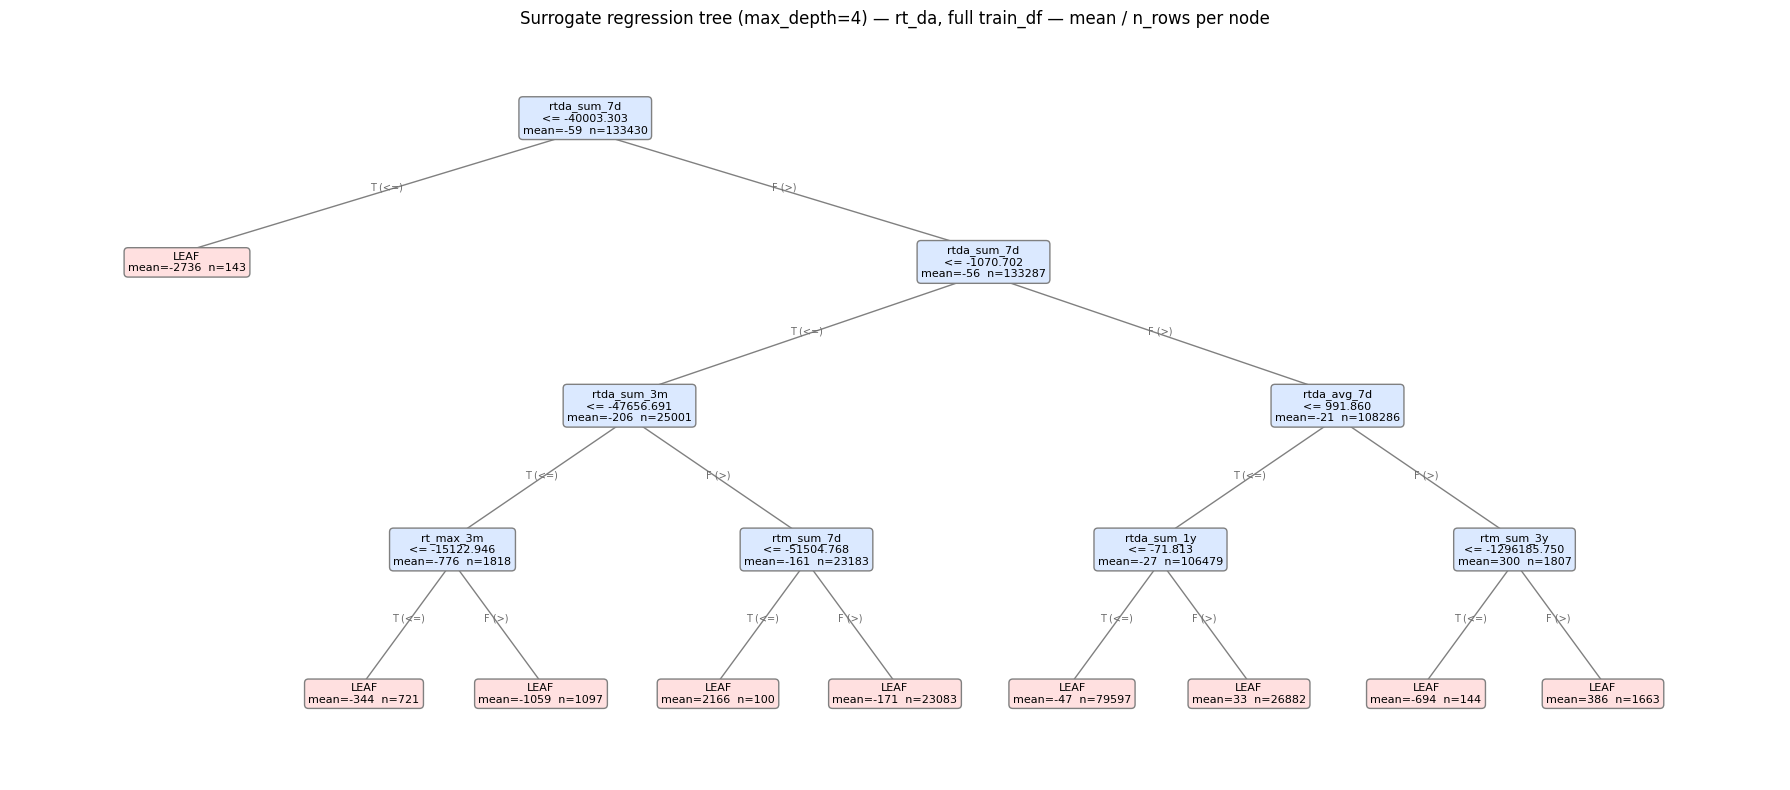

In [31]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, full train_df — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Design cut and reflect it on the portfolio and calculate the P&L 

In [ ]:
# exposure = pd.read_csv(file_loc + 'exposure_dthr.csv')
# # stream bid_dthr.csv in chunks, keep only short_profit > 0 (avoids loading the whole file)

In [7]:
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')
from nighthawk.util.bigquery_functions import download_df_from_bq

sql = 'SELECT * FROM `movetocloud-999.qctest.SPP_profit_dfax_repfam`'
bids = download_df_from_bq(sql, print_flag=True)

Query size 6623.378 MB   Est. Cost @$6.25/TB: $ 0.039
time_taken for downloading df from bq:  2.6  minutes


In [9]:
len(bids)

57826076

# Shrink bids by constraint-family-day scale factor

Same idea as the SPP scale-table BQ step, done locally on `bids` + `train_df`:
decide a shrink factor per **(dt, constraint_family_num)**, then push it down to the
node-level `bid_mw` through each node's dfax to that family (directional, |dfax|>cutoff,
most-aggressive cut when a node loads several risky families).

In [32]:
import numpy as np, pandas as pd

def scale_bids_by_family(bids, scale_df, dfax_cutoff=0.05,
                         factor_col='final_factor', kv_groups=None):
    """Push a per-(dt, constraint_family_num) shrink factor down to node-level bids.

    bids     : one row per (dt, node_num, incdec, constraint_family_num); bid_mw repeats
               across the families a node loads. Needs columns: dfax, bid_mw.
    scale_df : per (dt, constraint_family_num) with `factor_col` (<=1 shrinks, 1 = keep),
               optionally a KV_group column (only used when kv_groups is passed).
    returns  : one row per (dt, node_num, incdec) with node_factor, bid_mw_original, scaled_bid_mw.
    """
    b = bids.copy(); b['dt'] = b['dt'].astype(str)
    s = scale_df.copy(); s['dt'] = s['dt'].astype(str)
    keep = ['dt', 'constraint_family_num', factor_col] + (['KV_group'] if kv_groups else [])
    b = b.merge(s[keep], on=['dt', 'constraint_family_num'], how='left')

    # a family only shrinks the side its dfax loads:
    #   dfax>0 -> injecting (Increment) raises flow;  dfax<0 -> withdrawing (Decrement) raises flow
    inc_side = (b['incdec'] == 'Increment') & (b['dfax'] > 0)
    dec_side = (b['incdec'] == 'Decrement') & (b['dfax'] < 0)
    eligible = (inc_side | dec_side) & (b['dfax'].abs() > dfax_cutoff) & b[factor_col].notna()
    if kv_groups is not None:
        eligible &= b['KV_group'].isin(kv_groups)
    b['row_factor'] = np.where(eligible, b[factor_col], 1.0)

    # most aggressive cut across every family that loads this node-bid (mirrors MIN() in the BQ step)
    node_factor = (b.groupby(['dt', 'node_num', 'incdec'])['row_factor']
                     .min().rename('node_factor').reset_index())
    # collapse the exploded bids back to one row per (dt, node, incdec)
    node_bids = (b.drop_duplicates(['dt', 'node_num', 'incdec'])
                   [['dt', 'node_num', 'incdec', 'bid_mw']]
                   .merge(node_factor, on=['dt', 'node_num', 'incdec'], how='left'))
    node_bids['node_factor'] = node_bids['node_factor'].fillna(1.0)
    node_bids['bid_mw_original'] = node_bids['bid_mw']
    node_bids['scaled_bid_mw'] = node_bids['bid_mw'] * node_bids['node_factor']
    return node_bids


In [33]:
# ---- how much flow each (dt, constraint_family_num) is loaded with, by side ----
# exposure = MW of flow the bids push onto the constraint = bid_mw * |dfax|
DFAX_CUTOFF = 0.05
_e = bids[bids['dfax'].abs() > DFAX_CUTOFF].copy()
_e = _e[((_e['incdec'] == 'Increment') & (_e['dfax'] > 0)) |
        ((_e['incdec'] == 'Decrement') & (_e['dfax'] < 0))]
_e['flow_mw'] = _e['bid_mw'] * _e['dfax'].abs()   # bid MW -> flow on the constraint
family_day_exposure = (_e.groupby(['dt', 'constraint_family_num'])
                         .agg(family_bid_mw=('bid_mw', 'sum'),
                              family_flow_mw=('flow_mw', 'sum')).reset_index())
print('family-day exposures:', family_day_exposure.shape[0])
display(family_day_exposure.sort_values('family_flow_mw', ascending=False).head())


family-day exposures: 1385892


,dt,constraint_family_num,family_bid_mw,family_flow_mw
200010,2022-02-15,902.0,13480.267235,6628.948426
196898,2022-02-11,902.0,13151.496536,6439.595844
101417,2021-09-26,902.0,16448.450682,5803.766479
195379,2022-02-08,902.0,9833.409222,4765.924727
900150,2024-09-06,902.0,13978.692311,4755.503206


In [16]:
portfolio_df = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')

In [50]:
# ---- build the per-family-day shrink factor from train_df (EDIT this rule) ----
# train_df is at (dt, constraint_family_num) level. Set final_factor per family-day:
#   final_factor = 1.0  -> keep bid unchanged
#   final_factor < 1.0  -> shrink that family's node bids to that fraction
scale_df = train_df[['dt', 'constraint_family_num']].drop_duplicates().copy()
scale_df['final_factor'] = 1.0

# Option B - shrink to a target MW cap instead of a flat factor (uncomment to use):
TARGET_MW = 700.0
scale_df = scale_df.merge(family_day_exposure, on=['dt', 'constraint_family_num'], how='left')
scale_df['final_factor'] = np.where(scale_df['family_flow_mw'] > TARGET_MW,
                                    TARGET_MW / scale_df['family_flow_mw'], 1.0)
print(scale_df.sort_values(['final_factor'], ascending=True).head())

# ---- apply the factor down to node-level bids ----
scaled_bids = scale_bids_by_family(bids, scale_df, dfax_cutoff=DFAX_CUTOFF)
tot0, tot1 = scaled_bids['bid_mw_original'].sum(), scaled_bids['scaled_bid_mw'].sum()
print('node bids:', scaled_bids.shape[0], '| shrunk:', int((scaled_bids['node_factor'] < 1).sum()))
print(f'total bid MW  before={tot0:,.0f}  after={tot1:,.0f}  reduction={(1-tot1/tot0)*100:.1f}%')
display(scaled_bids[scaled_bids['node_factor'] < 1].head(10))


                dt  constraint_family_num  final_factor  family_bid_mw  \
375197  2024-09-06                    902      0.147198   13978.692311   
65855   2022-03-20                    902      0.152762    9873.500080   
320482  2024-04-22                    902      0.153455   11826.541503   
413731  2024-11-15                    902      0.162200   10963.383604   
80244   2022-04-22                    902      0.163577   16176.688269   

        family_flow_mw  
375197     4755.503206  
65855      4582.284100  
320482     4561.595644  
413731     4315.658553  
80244      4279.334613  
node bids: 200386 | shrunk: 88324
total bid MW  before=31,501,759  after=24,710,004  reduction=21.6%


,dt,node_num,incdec,bid_mw,node_factor,bid_mw_original,scaled_bid_mw
6,2022-04-22,1222.0,Decrement,71.613445,0.163577,71.613445,11.714300
7,2022-04-22,1222.0,Increment,432.476653,0.615901,432.476653,266.362747
8,2022-06-24,764.0,Decrement,46.800000,0.455131,46.800000,21.300111
14,2023-02-22,924.0,Decrement,528.125000,0.312800,528.125000,165.197583
15,2023-03-30,1357.0,Increment,1114.997310,0.508207,1114.997310,566.648997
20,2023-09-08,541.0,Decrement,113.750000,0.682544,113.750000,77.639365
28,2024-05-08,766.0,Increment,239.895000,0.688115,239.895000,165.075360
31,2024-09-02,1490.0,Decrement,123.025000,0.231846,123.025000,28.522826
32,2024-10-07,1039.0,Increment,145.269431,0.884277,145.269431,128.458456
33,2024-11-24,1282.0,Increment,613.250000,0.556561,613.250000,341.310761


In [63]:
# ---- apply node_factor onto the hourly portfolio_df, keyed by (dt, node_num, incdec) ----
nf = scaled_bids[['dt', 'node_num', 'incdec', 'node_factor']].copy()
nf['dt'] = nf['dt'].astype(str); nf['node_num'] = nf['node_num'].astype(int)

portfolio_df['dt'] = portfolio_df['dt'].astype(str)
portfolio_df['node_num'] = portfolio_df['node_num'].astype(int)

portfolio_df = portfolio_df.merge(nf, on=['dt', 'node_num', 'incdec'], how='left')
portfolio_df['node_factor'] = portfolio_df['node_factor'].fillna(1.0)   # untouched bids pass through
portfolio_df['bid_mw_original'] = portfolio_df['bid_mw']
portfolio_df['bid_mw'] = portfolio_df['bid_mw'] * portfolio_df['node_factor']

tot0, tot1 = portfolio_df['bid_mw_original'].sum(), portfolio_df['bid_mw'].sum()
print('portfolio rows:', len(portfolio_df), '| scaled rows:', int((portfolio_df['node_factor'] < 1).sum()))
print(f'total bid MW  before={tot0:,.0f}  after={tot1:,.0f}  reduction={(1-tot1/tot0)*100:.2f}%')
portfolio_df.head()


portfolio rows: 10237060 | scaled rows: 4977989
total bid MW  before=31,501,815  after=24,710,047  reduction=21.56%


,dt,strategy,hr,incdec,segment,node_num,bid_mw,bid_price,capacity,node_factor,bid_mw_original
0,2021-06-02,Darwin,1,Increment,11.0,30,1.8,21.856845,medium,1.0,1.8
1,2021-06-02,Darwin,1,Increment,10.0,172,1.8,15.583938,medium,1.0,1.8
2,2021-06-02,Darwin,1,Increment,11.0,172,1.8,18.105542,medium,1.0,1.8
3,2021-06-02,Darwin,1,Increment,11.0,269,1.8,18.700198,low,1.0,1.8
4,2021-06-02,Darwin,1,Decrement,7.0,293,1.8,20.551130,low,1.0,1.8


In [44]:
selected = bids.query('dt == "2024-09-06" and constraint_family_num == 902')

In [47]:
new_select = selected.query('(incdec == "Decrement" and dfax<0) or (incdec == "Increment" and dfax>0) ')

In [66]:
# file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
# port = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

In [67]:
# create the pnl table for each day, long mws and short mws for each constraint family num and the pnl in the column 
# first create the daily constraint family num short bid mws and long bid mws and then clear mws 
import gc
def calculate_derived_profit_cols(df, da_total_col = 'da_total', min_mw = 0.1, bid_mw_col = 'bid_mw', bid_price_col = 'bid_price'):
    df = df[df[bid_mw_col] > min_mw].copy()
    
    df['clear_mw'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * (df['bid_price'] > df[da_total_col]),
                              df[bid_mw_col] * (df['bid_price'] < df[da_total_col])).round(1)
    df['profit'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] *
                            (df['rt_total'] - df[da_total_col] -
                             df['op_rate_dec_a']),
                            df['clear_mw'] *
                            (df[da_total_col] - df['rt_total'] - df['op_rate_inc_a']))
    df['profit_congestion'] = np.where(df['incdec'] == 'Decrement',
                                       df['clear_mw'] *
                                       (df['rt_congestion'] -
                                        df['da_congestion']),
                                       df['clear_mw'] *
                                       (df['da_congestion'] - df['rt_congestion']))
    df['profit_slack'] = np.where(df['incdec'] == 'Decrement',
                                  df['clear_mw'] *
                                  (df['rt_slack'] - df['da_slack']),
                                  df['clear_mw'] *
                                  (df['da_slack'] - df['rt_slack']))
    df['profit_oprate'] = np.where(df['incdec'] == 'Decrement', -df['clear_mw'] * df['op_rate_dec_a'],
                                   -df['clear_mw'] * df['op_rate_inc_a'])

    if 'SPP'.upper() == 'SPP':  # collateral rule for SPP
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df[bid_mw_col] * df['bid_ref_price']),
                                       abs(df[bid_mw_col] * df['offer_ref_price']))
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['clear_mw'] * df['bid_ref_price']),
                                        abs(df['clear_mw'] * df['offer_ref_price']))
    else:
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * df['bid_ref_price'],
                                       df[bid_mw_col] * df['offer_ref_price'])
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] * df['bid_ref_price'],
                                        df['clear_mw'] * df['offer_ref_price'])

    df['profit_pos'] = np.maximum(df['profit'], 0)
    df['profit_neg'] = np.minimum(df['profit'], 0)
    df['investment'] = df['clear_mw'] * df[da_total_col]
    df['investment'] = np.where(df['incdec'] == 'Increment', df['investment'], -df['investment'])
    return df
profit_table_new  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw')
profit_table_old  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw_original')


del ref_df            # merged into profit_table; not used afterward
gc.collect()

1979

In [70]:
profit_table_new.profit_congestion.sum()

np.float64(43170637.54563)